In [2]:
# Import necessary libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
import os
import time
from typing import Dict, List, Tuple, Optional, Union

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [3]:
class HyperspectralCAE(nn.Module):
    """
    A 4D convolutional autoencoder for hyperspectral data aggregation.
    Adapted from the architecture described in the paper "A Convolutional Autoencoder
    for Multi-Subject fMRI Data Aggregation".

    This model takes full-resolution hyperspectral data from multiple excitation wavelengths
    and finds shared patterns across them while preserving spatial locality.
    """

    def __init__(
        self,
        num_excitations: int,
        input_height: int,
        input_width: int,
        num_emission_bands: int,
        k1: int = 20,  # Number of filters in first layer
        k3: int = 20,  # Number of filters in third layer
        filter_size: int = 5,
        sparsity_target: float = 0.75,
        sparsity_weight: float = 1.0,
        dropout_rate: float = 0.5
    ):
        """
        Initialize the Hyperspectral Convolutional Autoencoder.

        Args:
            num_excitations: Number of excitation wavelengths
            input_height: Height of input images
            input_width: Width of input images
            num_emission_bands: Number of emission wavelength bands
            k1: Number of filters in first layer
            k3: Number of filters in shared feature maps
            filter_size: Size of convolutional filters
            sparsity_target: Target sparsity for regularization
            sparsity_weight: Weight of sparsity regularization
            dropout_rate: Dropout probability
        """
        super(HyperspectralCAE, self).__init__()

        self.num_excitations = num_excitations
        self.input_height = input_height
        self.input_width = input_width
        self.num_emission_bands = num_emission_bands
        self.filter_size = filter_size
        self.k1 = k1
        self.k3 = k3
        self.sparsity_target = sparsity_target
        self.sparsity_weight = sparsity_weight
        self.dropout_rate = dropout_rate

        padding = filter_size // 2

        # Encoder
        # First layer: Excitation-specific 3D convolutions
        # Instead of making separate convolution layers for each excitation wavelength,
        # we use grouped convolutions where each group corresponds to an excitation wavelength
        self.enc_conv1 = nn.Conv3d(
            in_channels=num_excitations,
            out_channels=num_excitations * k1,
            kernel_size=(filter_size, filter_size, min(5, num_emission_bands)),
            padding=(padding, padding, min(5, num_emission_bands) // 2),
            groups=num_excitations  # Each group processes one excitation wavelength
        )

        # Second layer: Average pooling across excitation dimension
        # This is handled in forward() with reshaping and mean operations

        # Third layer: Convolution on shared feature maps
        self.enc_conv3 = nn.Conv3d(
            in_channels=k1,
            out_channels=k3,
            kernel_size=(filter_size, filter_size, 1),
            padding=(padding, padding, 0)
        )

        # Dropout
        self.dropout = nn.Dropout(dropout_rate)

        # Decoder
        # Reverse the encoding process
        self.dec_conv1 = nn.Conv3d(
            in_channels=k3,
            out_channels=k1,
            kernel_size=(filter_size, filter_size, 1),
            padding=(padding, padding, 0)
        )

        # Final layer: Reconstruct each excitation wavelength
        self.dec_conv2 = nn.Conv3d(
            in_channels=k1,
            out_channels=num_excitations,
            kernel_size=(filter_size, filter_size, min(5, num_emission_bands)),
            padding=(padding, padding, min(5, num_emission_bands) // 2),
            groups=num_excitations  # Each group reconstructs one excitation wavelength
        )

    def encode(self, x):
        """
        Encode the input data to the shared feature representation.

        Args:
            x: Input tensor of shape (batch_size, num_excitations, height, width, emission_bands)

        Returns:
            Shared feature maps
        """
        # Ensure input has right shape
        batch_size, num_excitations, height, width, emission_bands = x.shape
        assert num_excitations == self.num_excitations, "Input has wrong number of excitation wavelengths"

        # First layer: Excitation-specific 3D convolutions
        # Reshape to work with Conv3D (which expects [batch, channels, depth, height, width])
        x = x.permute(0, 1, 4, 2, 3)  # [batch, excitations, emission_bands, height, width]

        # Apply first convolution - produces excitation-specific feature maps
        x = self.enc_conv1(x)  # [batch, num_excitations*k1, emission_bands', height', width']
        x = F.tanh(x)

        # Reshape to separate excitation and filter dimensions
        x = x.view(batch_size, self.num_excitations, self.k1, x.shape[2], x.shape[3], x.shape[4])

        # Second layer: Average pooling across excitations
        x = torch.mean(x, dim=1)  # [batch, k1, emission_bands', height', width']

        # Third layer: Convolution on shared feature maps
        x = self.enc_conv3(x)  # [batch, k3, emission_bands', height', width']
        x = F.tanh(x)

        # Apply dropout
        x = self.dropout(x)

        return x

    def decode(self, x):
        """
        Decode from the shared feature representation back to reconstructed input.

        Args:
            x: Shared feature maps from the encoder

        Returns:
            Reconstructed data for each excitation wavelength
        """
        batch_size = x.shape[0]

        # First decoding layer
        x = self.dec_conv1(x)  # [batch, k1, emission_bands', height', width']
        x = F.tanh(x)

        # Expand to create copies for each excitation wavelength
        x = x.unsqueeze(1).expand(-1, self.num_excitations, -1, -1, -1, -1)
        x = x.reshape(batch_size, self.num_excitations * self.k1, *x.shape[3:])

        # Final decoding layer to reconstruct each excitation wavelength
        x = self.dec_conv2(x)  # [batch, num_excitations, emission_bands, height, width]

        # Reshape back to original format
        x = x.permute(0, 1, 3, 4, 2)  # [batch, excitations, height, width, emission_bands]

        return x

    def forward(self, x):
        """
        Forward pass through the autoencoder.

        Args:
            x: Input tensor of shape (batch_size, num_excitations, height, width, emission_bands)

        Returns:
            Reconstructed data
        """
        encoded = self.encode(x)
        decoded = self.decode(encoded)
        return decoded

    def compute_sparsity_loss(self, encoded):
        """
        Compute the sparsity regularization loss (KL divergence).

        Args:
            encoded: Encoded representation

        Returns:
            KL divergence loss
        """
        # Convert tanh activation to [0,1] range for sparsity computation
        rho_hat = 0.5 * (encoded + 1)

        # Average activation for each filter
        rho_hat = rho_hat.mean(dim=(0, 2, 3, 4))

        # Compute KL divergence
        rho = torch.tensor(self.sparsity_target).to(encoded.device)
        kl_loss = rho * torch.log(rho / rho_hat) + (1 - rho) * torch.log((1 - rho) / (1 - rho_hat))

        return kl_loss.sum()

In [4]:
class HyperspectralCAEVariable(nn.Module):
    """
    A 4D convolutional autoencoder for hyperspectral data aggregation with support
    for variable emission band lengths across different excitation wavelengths.
    """

    def __init__(
        self,
        excitations_data: Dict[float, np.ndarray],
        k1: int = 20,  # Number of filters in first layer
        k3: int = 20,  # Number of filters in third layer
        filter_size: int = 5,
        sparsity_target: float = 0.75,
        sparsity_weight: float = 1.0,
        dropout_rate: float = 0.5,
        debug: bool = False
    ):
        """
        Initialize the Hyperspectral Convolutional Autoencoder with variable band support.

        Args:
            excitations_data: Dictionary mapping excitation wavelengths to data arrays
                              with shape [height, width, emission_bands]
            k1: Number of filters in first layer
            k3: Number of filters in third layer
            filter_size: Size of convolutional filters
            sparsity_target: Target sparsity for regularization
            sparsity_weight: Weight of sparsity regularization
            dropout_rate: Dropout probability
            debug: Whether to print debug information
        """
        super(HyperspectralCAEVariable, self).__init__()

        self.excitation_wavelengths = sorted(list(excitations_data.keys()))
        self.num_excitations = len(self.excitation_wavelengths)
        self.debug = debug

        # Store mapping from excitation wavelength to sanitized key
        self.ex_to_key = {ex: self._sanitize_key(ex) for ex in self.excitation_wavelengths}
        self.key_to_ex = {key: ex for ex, key in self.ex_to_key.items()}

        # Get spatial dimensions (assumed same for all excitations)
        first_ex = self.excitation_wavelengths[0]
        height, width, _ = excitations_data[first_ex].shape
        self.input_height = height
        self.input_width = width

        # Store emission band counts for each excitation
        self.emission_bands = {ex: data.shape[2] for ex, data in excitations_data.items()}

        self.filter_size = filter_size
        self.k1 = k1
        self.k3 = k3
        self.sparsity_target = sparsity_target
        self.sparsity_weight = sparsity_weight
        self.dropout_rate = dropout_rate

        padding = filter_size // 2

        # Create separate encoder convolutions for each excitation wavelength
        # to handle different emission band counts
        self.enc_conv1 = nn.ModuleDict()
        for ex in self.excitation_wavelengths:
            key = self.ex_to_key[ex]
            num_bands = self.emission_bands[ex]
            self.enc_conv1[key] = nn.Conv3d(
                in_channels=1,  # One channel per excitation
                out_channels=k1,
                kernel_size=(filter_size, filter_size, min(5, num_bands)),
                padding=(padding, padding, min(5, num_bands) // 2)
            )

        # Third layer: Convolution on shared feature maps
        self.enc_conv3 = nn.Conv3d(
            in_channels=k1,
            out_channels=k3,
            kernel_size=(filter_size, filter_size, 1),
            padding=(padding, padding, 0)
        )

        # Dropout
        self.dropout = nn.Dropout(dropout_rate)

        # Decoder
        self.dec_conv1 = nn.Conv3d(
            in_channels=k3,
            out_channels=k1,
            kernel_size=(filter_size, filter_size, 1),
            padding=(padding, padding, 0)
        )

        # Separate decoders for each excitation wavelength
        self.dec_conv2 = nn.ModuleDict()
        for ex in self.excitation_wavelengths:
            key = self.ex_to_key[ex]
            num_bands = self.emission_bands[ex]
            self.dec_conv2[key] = nn.Conv3d(
                in_channels=k1,
                out_channels=num_bands,  # Output one channel per emission band
                kernel_size=(filter_size, filter_size, 1),
                padding=(padding, padding, 0)
            )

    def _sanitize_key(self, key):
        """Convert a key to a valid ModuleDict key by replacing dots with underscores."""
        return str(key).replace('.', '_')

    def encode(self, data_dict):
        """
        Encode the input data to the shared feature representation.

        Args:
            data_dict: Dictionary mapping excitation wavelengths to tensors
                      with shape [batch_size, height, width, emission_bands]

        Returns:
            Shared feature maps
        """
        batch_size = next(iter(data_dict.values())).shape[0]

        # Process each excitation wavelength separately
        feature_maps = []

        for ex in self.excitation_wavelengths:
            if ex not in data_dict:
                continue

            # Get data for this excitation
            x = data_dict[ex]

            if self.debug:
                print(f"Input data for ex={ex}: {x.shape}")

            # Add channel dimension and permute to [batch, channel, emission_bands, height, width]
            x = x.permute(0, 3, 1, 2).unsqueeze(1)

            if self.debug:
                print(f"After permute for ex={ex}: {x.shape}")

            # Apply first convolution (using sanitized key)
            key = self.ex_to_key[ex]
            x = self.enc_conv1[key](x)
            x = F.tanh(x)

            if self.debug:
                print(f"After enc_conv1 for ex={ex}: {x.shape}")

            # Standardize the emission bands dimension using adaptive pooling
            # This ensures all tensors have the same shape regardless of input emission bands
            x = F.adaptive_avg_pool3d(x, (1, x.shape[3], x.shape[4]))

            if self.debug:
                print(f"After adaptive_pool for ex={ex}: {x.shape}")

            # Add to feature maps
            feature_maps.append(x)

        # Stack feature maps along channel dimension and average
        if not feature_maps:
            raise ValueError("No valid excitation wavelengths found in input data")

        stacked = torch.stack(feature_maps, dim=1)

        if self.debug:
            print(f"Stacked feature maps: {stacked.shape}")

        mean_features = torch.mean(stacked, dim=1)

        if self.debug:
            print(f"Mean features: {mean_features.shape}")

        # Apply third layer convolution
        encoded = self.enc_conv3(mean_features)
        encoded = F.tanh(encoded)

        if self.debug:
            print(f"Encoded: {encoded.shape}")

        # Apply dropout
        encoded = self.dropout(encoded)

        return encoded

    def decode(self, encoded):
        """
        Decode from the shared feature representation back to reconstructed input.

        Args:
            encoded: Shared feature maps from the encoder

        Returns:
            Dictionary mapping excitation wavelengths to reconstructed data
        """
        if self.debug:
            print(f"Encoded shape in decode: {encoded.shape}")

        # First decoding layer
        x = self.dec_conv1(encoded)
        x = F.tanh(x)

        if self.debug:
            print(f"After dec_conv1: {x.shape}")

        # Decode separately for each excitation wavelength
        reconstructed = {}

        for ex in self.excitation_wavelengths:
            # Apply final convolution for this excitation (using sanitized key)
            key = self.ex_to_key[ex]
            num_bands = self.emission_bands[ex]

            # Get this excitation's decoder and apply it to generate all emission bands at once
            recon = self.dec_conv2[key](x)

            if self.debug:
                print(f"After dec_conv2 for ex={ex}: {recon.shape}")

            # Apply activation
            recon = F.tanh(recon)

            # Reshape back to original format [batch, height, width, emission_bands]
            # Need to squeeze out dimension with size 1 first
            recon = recon.squeeze(2)  # Remove the dimension with size 1

            if self.debug:
                print(f"After squeeze for ex={ex}: {recon.shape}")

            # Now permute the remaining dimensions
            recon = recon.permute(0, 2, 3, 1)  # [batch, height, width, emission_bands]

            if self.debug:
                print(f"After permute for ex={ex}: {recon.shape}")

            reconstructed[ex] = recon

        return reconstructed

    def forward(self, data_dict):
        """
        Forward pass through the autoencoder.

        Args:
            data_dict: Dictionary mapping excitation wavelengths to tensors

        Returns:
            Reconstructed data dictionary
        """
        encoded = self.encode(data_dict)
        decoded = self.decode(encoded)
        return decoded

    def compute_sparsity_loss(self, encoded):
        """
        Compute the sparsity regularization loss (KL divergence).

        Args:
            encoded: Encoded representation

        Returns:
            KL divergence loss
        """
        # Convert tanh activation to [0,1] range for sparsity computation
        rho_hat = 0.5 * (encoded + 1)

        # Average activation for each filter
        rho_hat = rho_hat.mean(dim=(0, 2, 3, 4))

        # Compute KL divergence
        rho = torch.tensor(self.sparsity_target).to(encoded.device)
        kl_loss = rho * torch.log(rho / rho_hat) + (1 - rho) * torch.log((1 - rho) / (1 - rho_hat))

        return kl_loss.sum()

In [5]:
class HyperspectralDataset(Dataset):
    """
    Dataset for loading full-resolution hyperspectral data for the autoencoder.
    Handles variable emission band lengths across different excitation wavelengths.
    """

    def __init__(self, data_dict: Dict, excitation_wavelengths: List[float]=None,
                 normalize: bool = True, downscale_factor: int = 1,
                 roi: Optional[Tuple[int, int, int, int]] = None):
        """
        Initialize the dataset from the hyperspectral data dictionary.

        Args:
            data_dict: Dictionary containing hyperspectral data (output from HyperspectralDataLoader)
            excitation_wavelengths: List of excitation wavelengths to use
            normalize: Whether to normalize the data
            downscale_factor: Factor to downscale the spatial dimensions (1 = full resolution)
            roi: Region of interest as (row_min, row_max, col_min, col_max)
        """
        self.data_dict = data_dict
        self.normalize = normalize
        self.downscale_factor = downscale_factor
        self.roi = roi

        # If no excitation wavelengths are specified, use all available
        if excitation_wavelengths is None:
            self.excitation_wavelengths = [
                float(ex) for ex in data_dict['excitation_wavelengths']
            ]
        else:
            self.excitation_wavelengths = excitation_wavelengths

        # Prepare data
        self._prepare_data()

    def _prepare_data(self):
        """
        Prepare the hyperspectral data for training:
        1. Extract the full resolution data or specified ROI for each excitation wavelength
        2. Downscale if requested
        3. Handle variable emission band lengths
        4. Stack all data and normalize
        """
        print(f"Preparing data for {len(self.excitation_wavelengths)} excitation wavelengths...")

        # First, determine spatial dimensions and check emission band lengths
        emission_band_lengths = {}
        height = None
        width = None

        for ex in self.excitation_wavelengths:
            ex_str = str(ex)
            if ex_str not in self.data_dict['data']:
                print(f"Warning: Excitation wavelength {ex} not found in data dictionary")
                continue

            cube = self.data_dict['data'][ex_str]['cube']
            h, w, bands = cube.shape

            if height is None:
                height = h
                width = w

            # Store emission band length for this excitation
            emission_band_lengths[ex] = bands

            # Store wavelengths
            if hasattr(self.data_dict['data'][ex_str], 'wavelengths'):
                wavelengths = self.data_dict['data'][ex_str]['wavelengths']
            else:
                wavelengths = list(range(bands))  # Fallback if wavelengths not provided

        # Print emission band information
        print("Emission band lengths for each excitation wavelength:")
        for ex, bands in emission_band_lengths.items():
            print(f"  - Excitation {ex} nm: {bands} bands")

        # Apply ROI if specified
        if self.roi:
            row_min, row_max, col_min, col_max = self.roi
            height, width = row_max - row_min, col_max - col_min
            print(f"Using ROI: ({row_min}:{row_max}, {col_min}:{col_max})")
        else:
            row_min, row_max = 0, height
            col_min, col_max = 0, width

        # Apply downscaling if requested
        if self.downscale_factor > 1:
            height = height // self.downscale_factor
            width = width // self.downscale_factor
            print(f"Downscaling by factor of {self.downscale_factor} to {height}x{width}")

        # Prepare data for each excitation wavelength separately
        self.processed_data = {}
        self.emission_wavelengths = {}

        for ex in self.excitation_wavelengths:
            ex_str = str(ex)
            if ex_str not in self.data_dict['data']:
                continue

            cube = self.data_dict['data'][ex_str]['cube']

            # Get emission wavelengths for this excitation
            if 'wavelengths' in self.data_dict['data'][ex_str]:
                self.emission_wavelengths[ex] = self.data_dict['data'][ex_str]['wavelengths']

            # Apply ROI
            roi_data = cube[row_min:row_max, col_min:col_max, :]

            # Apply downscaling if needed
            if self.downscale_factor > 1:
                num_bands = roi_data.shape[2]
                downscaled_data = np.zeros((height, width, num_bands))

                for h in range(height):
                    for w in range(width):
                        h_start = h * self.downscale_factor
                        h_end = min((h + 1) * self.downscale_factor, roi_data.shape[0])
                        w_start = w * self.downscale_factor
                        w_end = min((w + 1) * self.downscale_factor, roi_data.shape[1])

                        block = roi_data[h_start:h_end, w_start:w_end, :]
                        # Average over spatial dimensions only
                        downscaled_data[h, w, :] = np.mean(block, axis=(0, 1))

                processed = downscaled_data
            else:
                processed = roi_data

            # Handle NaN values
            if np.isnan(processed).any():
                print(f"Warning: NaN values detected in excitation {ex}. Replacing with zeros.")
                processed = np.nan_to_num(processed, nan=0.0)

            # Store processed data for this excitation
            self.processed_data[ex] = processed

        # Normalize if requested
        if self.normalize:
            # Find global min and max across all excitations
            data_min = float('inf')
            data_max = float('-inf')

            for ex, data in self.processed_data.items():
                local_min = np.min(data)
                local_max = np.max(data)
                data_min = min(data_min, local_min)
                data_max = max(data_max, local_max)

            # Normalize each excitation to [-1, 1]
            for ex in self.processed_data:
                self.processed_data[ex] = 2 * (self.processed_data[ex] - data_min) / (data_max - data_min) - 1

            # Store normalization parameters for later use
            self.normalization_params = {
                'min': data_min,
                'max': data_max
            }

            print(f"Data normalized to range [-1, 1] (original range: [{data_min:.4f}, {data_max:.4f}])")

        print(f"Data preparation complete. Spatial dimensions: {height}x{width}")

    def __len__(self):
        # For full-resolution data, we have only one sample per excitation
        return len(self.processed_data)

    def __getitem__(self, idx):
        """
        Get the data for a specific excitation wavelength.

        Args:
            idx: Index of the excitation wavelength to retrieve

        Returns:
            Data tensor for that excitation
        """
        # Convert index to excitation wavelength
        if idx >= len(self.excitation_wavelengths):
            raise IndexError(f"Index {idx} out of range for {len(self.excitation_wavelengths)} excitation wavelengths")

        ex = self.excitation_wavelengths[idx]

        if ex not in self.processed_data:
            raise ValueError(f"No processed data available for excitation {ex}")

        # Return as tensor
        return torch.tensor(self.processed_data[ex], dtype=torch.float32)

    def get_all_data(self):
        """
        Get all processed data as a dictionary.

        Returns:
            Dictionary mapping excitation wavelengths to processed data tensors
        """
        return {ex: torch.tensor(data, dtype=torch.float32)
                for ex, data in self.processed_data.items()}

    def get_spatial_dimensions(self):
        """
        Get the spatial dimensions of the processed data.

        Returns:
            Height and width as a tuple
        """
        # Get first available excitation
        first_ex = list(self.processed_data.keys())[0]
        height, width, _ = self.processed_data[first_ex].shape
        return height, width

# Function to load data using the HyperspectralDataLoader
def load_hyperspectral_data(data_path):
    """
    Load hyperspectral data from a pickle file.

    Args:
        data_path: Path to the pickle file containing hyperspectral data

    Returns:
        Loaded data dictionary
    """
    print(f"Loading data from {data_path}...")
    with open(data_path, 'rb') as f:
        data_dict = pickle.load(f)

    # Print a summary of the loaded data
    print("Data Summary:")
    print(f"Number of excitation wavelengths: {len(data_dict['excitation_wavelengths'])}")
    print(f"Excitation wavelengths: {data_dict['excitation_wavelengths']}")

    # Check the first excitation wavelength
    first_ex = str(data_dict['excitation_wavelengths'][0])
    if first_ex in data_dict['data']:
        cube_shape = data_dict['data'][first_ex]['cube'].shape
        print(f"Data shape for first excitation ({first_ex} nm): {cube_shape}")

    return data_dict

In [6]:
def create_spatial_chunks(data_tensor, chunk_size=128, overlap=16):
    """
    Split a large spatial hyperspectral tensor into overlapping chunks for memory-efficient processing.

    Args:
        data_tensor: Input tensor of shape [num_excitations, height, width, emission_bands]
        chunk_size: Size of each spatial chunk
        overlap: Overlap between adjacent chunks

    Returns:
        List of chunk tensors and their positions (y_start, y_end, x_start, x_end)
    """
    # Get dimensions
    num_excitations, height, width, num_bands = data_tensor.shape

    # Calculate stride
    stride = chunk_size - overlap

    # Calculate number of chunks in each dimension
    num_chunks_y = max(1, (height - overlap) // stride)
    num_chunks_x = max(1, (width - overlap) // stride)

    # Adjust to ensure we cover the entire image
    if stride * num_chunks_y + overlap < height:
        num_chunks_y += 1
    if stride * num_chunks_x + overlap < width:
        num_chunks_x += 1

    # Create list to store chunks and their positions
    chunks = []
    positions = []

    # Extract chunks
    for i in range(num_chunks_y):
        for j in range(num_chunks_x):
            # Calculate start and end positions
            y_start = i * stride
            x_start = j * stride
            y_end = min(y_start + chunk_size, height)
            x_end = min(x_start + chunk_size, width)

            # Handle edge cases by adjusting start positions
            if y_end == height:
                y_start = max(0, height - chunk_size)
            if x_end == width:
                x_start = max(0, width - chunk_size)

            # Extract chunk
            chunk = data_tensor[:, y_start:y_end, x_start:x_end, :]

            # Add to lists
            chunks.append(chunk)
            positions.append((y_start, y_end, x_start, x_end))

    print(f"Created {len(chunks)} chunks of size {chunk_size}x{chunk_size} with {overlap} overlap")
    return chunks, positions


def merge_chunk_reconstructions(chunks, positions, full_height, full_width):
    """
    Merge the reconstructed chunks back into a full image.
    For overlapping regions, take the average of the reconstructions.

    Args:
        chunks: List of reconstructed chunk tensors [batch, num_excitations, height, width, emission_bands]
        positions: List of positions (y_start, y_end, x_start, x_end) for each chunk
        full_height: Height of the full reconstructed image
        full_width: Width of the full reconstructed image

    Returns:
        Merged full reconstruction
    """
    # Get dimensions from the first chunk
    batch_size, num_excitations, _, _, num_bands = chunks[0].shape

    # Create empty tensor for merged result
    merged = torch.zeros((batch_size, num_excitations, full_height, full_width, num_bands),
                        device=chunks[0].device)

    # Create weight tensor to track how many times each pixel is updated
    weights = torch.zeros((batch_size, num_excitations, full_height, full_width, num_bands),
                         device=chunks[0].device)

    # Merge chunks
    for chunk, (y_start, y_end, x_start, x_end) in zip(chunks, positions):
        # Add chunk to merged result
        merged[:, :, y_start:y_end, x_start:x_end, :] += chunk

        # Update weights
        weights[:, :, y_start:y_end, x_start:x_end, :] += 1

    # Average overlapping regions
    merged = merged / torch.clamp(weights, min=1.0)

    return merged

In [7]:
def create_spatial_chunks(data_tensor, chunk_size=128, overlap=16):
    """
    Split a large spatial hyperspectral tensor into overlapping chunks for memory-efficient processing.

    Args:
        data_tensor: Input tensor of shape [num_excitations, height, width, emission_bands]
        chunk_size: Size of each spatial chunk
        overlap: Overlap between adjacent chunks

    Returns:
        List of chunk tensors and their positions (y_start, y_end, x_start, x_end)
    """
    # Get dimensions
    num_excitations, height, width, num_bands = data_tensor.shape

    # Calculate stride
    stride = chunk_size - overlap

    # Calculate number of chunks in each dimension
    num_chunks_y = max(1, (height - overlap) // stride)
    num_chunks_x = max(1, (width - overlap) // stride)

    # Adjust to ensure we cover the entire image
    if stride * num_chunks_y + overlap < height:
        num_chunks_y += 1
    if stride * num_chunks_x + overlap < width:
        num_chunks_x += 1

    # Create list to store chunks and their positions
    chunks = []
    positions = []

    # Extract chunks
    for i in range(num_chunks_y):
        for j in range(num_chunks_x):
            # Calculate start and end positions
            y_start = i * stride
            x_start = j * stride
            y_end = min(y_start + chunk_size, height)
            x_end = min(x_start + chunk_size, width)

            # Handle edge cases by adjusting start positions
            if y_end == height:
                y_start = max(0, height - chunk_size)
            if x_end == width:
                x_start = max(0, width - chunk_size)

            # Extract chunk
            chunk = data_tensor[:, y_start:y_end, x_start:x_end, :]

            # Add to lists
            chunks.append(chunk)
            positions.append((y_start, y_end, x_start, x_end))

    print(f"Created {len(chunks)} chunks of size {chunk_size}x{chunk_size} with {overlap} overlap")
    return chunks, positions


def merge_chunk_reconstructions(chunks, positions, full_height, full_width):
    """
    Merge the reconstructed chunks back into a full image.
    For overlapping regions, take the average of the reconstructions.

    Args:
        chunks: List of reconstructed chunk tensors [batch, num_excitations, height, width, emission_bands]
        positions: List of positions (y_start, y_end, x_start, x_end) for each chunk
        full_height: Height of the full reconstructed image
        full_width: Width of the full reconstructed image

    Returns:
        Merged full reconstruction
    """
    # Get dimensions from the first chunk
    batch_size, num_excitations, _, _, num_bands = chunks[0].shape

    # Create empty tensor for merged result
    merged = torch.zeros((batch_size, num_excitations, full_height, full_width, num_bands),
                        device=chunks[0].device)

    # Create weight tensor to track how many times each pixel is updated
    weights = torch.zeros((batch_size, num_excitations, full_height, full_width, num_bands),
                         device=chunks[0].device)

    # Merge chunks
    for chunk, (y_start, y_end, x_start, x_end) in zip(chunks, positions):
        # Add chunk to merged result
        merged[:, :, y_start:y_end, x_start:x_end, :] += chunk

        # Update weights
        weights[:, :, y_start:y_end, x_start:x_end, :] += 1

    # Average overlapping regions
    merged = merged / torch.clamp(weights, min=1.0)

    return merged

In [8]:
def train_full_resolution_cae(
    model,
    dataset,
    num_epochs=50,
    learning_rate=0.001,
    chunk_size=128,
    chunk_overlap=16,
    device='cuda' if torch.cuda.is_available() else 'cpu'
):
    """
    Train the hyperspectral convolutional autoencoder on full-resolution data
    using spatial chunking for memory efficiency.

    Args:
        model: HyperspectralCAE model
        dataset: HyperspectralDataset with full-resolution data
        num_epochs: Number of training epochs
        learning_rate: Learning rate for the optimizer
        chunk_size: Size of spatial chunks for processing
        chunk_overlap: Overlap between adjacent chunks
        device: Device to use for training

    Returns:
        Trained model and training losses
    """
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # Get the full data tensor
    full_data = dataset[0].to(device)

    # Get full dimensions
    num_excitations, full_height, full_width, num_bands = full_data.shape

    # Add a batch dimension
    full_data = full_data.unsqueeze(0)

    # Create spatial chunks for memory-efficient processing
    chunks, positions = create_spatial_chunks(
        full_data[0].cpu(), chunk_size=chunk_size, overlap=chunk_overlap
    )

    # Convert chunks to device and add batch dimension
    chunks = [chunk.unsqueeze(0).to(device) for chunk in chunks]

    # Track losses
    train_losses = []

    print(f"Starting training for {num_epochs} epochs...")
    for epoch in range(num_epochs):
        epoch_start_time = time.time()
        epoch_loss = 0.0

        # Train on each chunk
        for i, (chunk, position) in enumerate(zip(chunks, positions)):
            # Forward pass
            output = model(chunk)

            # Compute reconstruction loss
            recon_loss = F.mse_loss(output, chunk)

            # Compute sparsity loss
            encoded = model.encode(chunk)
            sparsity_loss = model.compute_sparsity_loss(encoded)

            # Total loss
            loss = recon_loss + model.sparsity_weight * sparsity_loss

            # Backward pass and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

            # Print progress for chunks
            if (i + 1) % 5 == 0 or i == len(chunks) - 1:
                print(f"  Processed {i+1}/{len(chunks)} chunks", end="\r")

        # Record average loss for this epoch
        avg_loss = epoch_loss / len(chunks)
        train_losses.append(avg_loss)

        epoch_time = time.time() - epoch_start_time
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}, Time: {epoch_time:.2f}s")

    return model, train_losses


def evaluate_full_resolution_cae(
    model,
    dataset,
    chunk_size=128,
    chunk_overlap=16,
    device='cuda' if torch.cuda.is_available() else 'cpu'
):
    """
    Evaluate the trained model on full-resolution data by reconstructing
    the entire hyperspectral cube.

    Args:
        model: Trained HyperspectralCAE model
        dataset: HyperspectralDataset with full-resolution data
        chunk_size: Size of spatial chunks for processing
        chunk_overlap: Overlap between adjacent chunks
        device: Device to use for evaluation

    Returns:
        Full reconstruction and evaluation metrics
    """
    model = model.to(device)
    model.eval()

    # Get the full data tensor
    full_data = dataset[0].to(device)

    # Get full dimensions
    num_excitations, full_height, full_width, num_bands = full_data.shape

    # Add a batch dimension
    full_data = full_data.unsqueeze(0)

    # Create spatial chunks for memory-efficient processing
    chunks, positions = create_spatial_chunks(
        full_data[0].cpu(), chunk_size=chunk_size, overlap=chunk_overlap
    )

    # Convert chunks to device and add batch dimension
    chunks = [chunk.unsqueeze(0).to(device) for chunk in chunks]

    # Process each chunk
    reconstructed_chunks = []
    with torch.no_grad():
        for i, chunk in enumerate(chunks):
            # Forward pass
            output = model(chunk)
            reconstructed_chunks.append(output)

            # Print progress
            if (i + 1) % 5 == 0 or i == len(chunks) - 1:
                print(f"  Processed {i+1}/{len(chunks)} chunks", end="\r")

    # Merge chunks into full reconstruction
    full_reconstruction = merge_chunk_reconstructions(
        reconstructed_chunks, positions, full_height, full_width
    )

    # Calculate metrics
    with torch.no_grad():
        # MSE for the full reconstruction
        mse = F.mse_loss(full_reconstruction, full_data).item()

        # Mean absolute error
        mae = torch.mean(torch.abs(full_reconstruction - full_data)).item()

        # PSNR (Peak Signal-to-Noise Ratio)
        # For normalized data in [-1, 1], the range is 2
        psnr = 10 * torch.log10(4.0 / mse).item()

    metrics = {
        'mse': mse,
        'mae': mae,
        'psnr': psnr
    }

    return full_reconstruction, metrics

In [9]:
def visualize_training_loss(losses):
    """
    Visualize the training loss curve.

    Args:
        losses: List of training losses
    """
    plt.figure(figsize=(10, 5))
    plt.plot(losses)
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.show()


def visualize_emission_spectrum(
    original_data,
    reconstructed_data,
    excitation_idx=0,
    y=None,
    x=None,
    wavelengths=None
):
    """
    Visualize the original and reconstructed emission spectrum at a specific spatial location.

    Args:
        original_data: Original data tensor [batch, num_excitations, height, width, emission_bands]
        reconstructed_data: Reconstructed data tensor [batch, num_excitations, height, width, emission_bands]
        excitation_idx: Index of excitation wavelength to visualize
        y, x: Spatial coordinates (if None, uses the center of the image)
        wavelengths: List of emission wavelengths (if available)
    """
    # Remove batch dimension if present
    if original_data.dim() == 5:
        original_data = original_data[0]
    if reconstructed_data.dim() == 5:
        reconstructed_data = reconstructed_data[0]

    # Get dimensions
    num_excitations, height, width, num_bands = original_data.shape

    # Use center coordinates if not specified
    if y is None:
        y = height // 2
    if x is None:
        x = width // 2

    # Extract spectra
    original_spectrum = original_data[excitation_idx, y, x, :].cpu().numpy()
    reconstructed_spectrum = reconstructed_data[excitation_idx, y, x, :].cpu().numpy()

    # Set up x-axis values
    x_values = wavelengths if wavelengths is not None else np.arange(num_bands)
    x_label = 'Emission Wavelength (nm)' if wavelengths is not None else 'Emission Band Index'

    # Create plot
    plt.figure(figsize=(12, 6))
    plt.plot(x_values, original_spectrum, 'b-', label='Original', linewidth=2)
    plt.plot(x_values, reconstructed_spectrum, 'r--', label='Reconstructed', linewidth=2)
    plt.title(f'Emission Spectrum at Position ({y}, {x}), Excitation #{excitation_idx}')
    plt.xlabel(x_label)
    plt.ylabel('Intensity (Normalized)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


def visualize_spatial_slice(
    original_data,
    reconstructed_data,
    excitation_idx=0,
    emission_idx=None,
    cmap='viridis'
):
    """
    Visualize a spatial slice of the original and reconstructed data.

    Args:
        original_data: Original data tensor [batch, num_excitations, height, width, emission_bands]
        reconstructed_data: Reconstructed data tensor [batch, num_excitations, height, width, emission_bands]
        excitation_idx: Index of excitation wavelength to visualize
        emission_idx: Index of emission band to visualize (if None, uses the middle band)
        cmap: Colormap for visualization
    """
    # Remove batch dimension if present
    if original_data.dim() == 5:
        original_data = original_data[0]
    if reconstructed_data.dim() == 5:
        reconstructed_data = reconstructed_data[0]

    # Get dimensions
    num_excitations, height, width, num_bands = original_data.shape

    # Use middle emission band if not specified
    if emission_idx is None:
        emission_idx = num_bands // 2

    # Extract spatial slices
    original_slice = original_data[excitation_idx, :, :, emission_idx].cpu().numpy()
    reconstructed_slice = reconstructed_data[excitation_idx, :, :, emission_idx].cpu().numpy()

    # Calculate absolute difference
    diff = np.abs(original_slice - reconstructed_slice)

    # Create figure with three subplots
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Plot original
    im0 = axes[0].imshow(original_slice, cmap=cmap)
    axes[0].set_title('Original')
    plt.colorbar(im0, ax=axes[0])

    # Plot reconstruction
    im1 = axes[1].imshow(reconstructed_slice, cmap=cmap)
    axes[1].set_title('Reconstructed')
    plt.colorbar(im1, ax=axes[1])

    # Plot difference
    im2 = axes[2].imshow(diff, cmap='hot')
    axes[2].set_title('Absolute Difference')
    plt.colorbar(im2, ax=axes[2])

    plt.tight_layout()
    plt.show()


def visualize_feature_maps(
    model,
    data_tensor,
    num_maps=16,
    cmap='viridis'
):
    """
    Visualize the feature maps from the encoder.

    Args:
        model: Trained HyperspectralCAE model
        data_tensor: Input data tensor [num_excitations, height, width, emission_bands]
        num_maps: Number of feature maps to visualize
        cmap: Colormap for visualization
    """
    # Ensure model is in eval mode
    model.eval()

    # Add batch dimension if needed
    if data_tensor.dim() == 4:
        data_tensor = data_tensor.unsqueeze(0)

    # Get encoded representation
    with torch.no_grad():
        encoded = model.encode(data_tensor)

    # Convert to numpy for plotting
    encoded_np = encoded.cpu().numpy()[0]  # Remove batch dimension

    # Determine grid size
    grid_size = int(np.ceil(np.sqrt(num_maps)))

    # Create figure
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(15, 15))

    # Flatten axes for easy indexing
    axes = axes.flatten()

    # Plot feature maps
    for i in range(min(num_maps, encoded_np.shape[0])):
        # Take a slice from the middle of the emission dimension
        middle_slice = encoded_np[i, encoded_np.shape[1]//2]

        # Plot
        im = axes[i].imshow(middle_slice, cmap=cmap)
        axes[i].set_title(f'Feature Map {i+1}')
        axes[i].axis('off')
        plt.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)

    # Hide any unused subplots
    for i in range(num_maps, len(axes)):
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()


def create_false_color_image(
    data_tensor,
    excitation_idx=0,
    band_indices=None,
    vmin=None,
    vmax=None
):
    """
    Create a false color RGB image from three emission bands.

    Args:
        data_tensor: Data tensor [batch, num_excitations, height, width, emission_bands]
                    or [num_excitations, height, width, emission_bands]
        excitation_idx: Index of excitation wavelength to use
        band_indices: List of three emission band indices for R, G, B channels
                     (if None, uses beginning, middle, and end bands)
        vmin, vmax: Min and max values for normalization (if None, uses min and max of the data)

    Returns:
        RGB image as numpy array
    """
    # Remove batch dimension if present
    if data_tensor.dim() == 5:
        data_tensor = data_tensor[0]

    # Get data for the specified excitation
    data = data_tensor[excitation_idx].cpu().numpy()

    # Get dimensions
    height, width, num_bands = data.shape

    # Use default band indices if not specified
    if band_indices is None:
        band_indices = [0, num_bands // 2, num_bands - 1]

    # Create RGB image
    rgb = np.stack([
        data[:, :, band_indices[0]],  # R
        data[:, :, band_indices[1]],  # G
        data[:, :, band_indices[2]]   # B
    ], axis=2)

    # Normalize
    if vmin is None:
        vmin = np.min(rgb)
    if vmax is None:
        vmax = np.max(rgb)

    rgb = (rgb - vmin) / (vmax - vmin)
    rgb = np.clip(rgb, 0, 1)

    return rgb


def visualize_false_color_comparison(
    original_data,
    reconstructed_data,
    excitation_idx=0,
    band_indices=None
):
    """
    Compare original and reconstructed data using false color visualization.

    Args:
        original_data: Original data tensor
        reconstructed_data: Reconstructed data tensor
        excitation_idx: Index of excitation wavelength to visualize
        band_indices: List of three emission band indices for R, G, B channels
    """
    # Create false color images
    rgb_original = create_false_color_image(
        original_data, excitation_idx, band_indices
    )
    rgb_reconstructed = create_false_color_image(
        reconstructed_data, excitation_idx, band_indices
    )

    # Calculate absolute difference
    diff = np.abs(rgb_original - rgb_reconstructed)
    diff = diff / np.max(diff)  # Normalize difference for visualization

    # Create figure
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Plot original
    axes[0].imshow(rgb_original)
    axes[0].set_title('Original (False Color)')
    axes[0].axis('off')

    # Plot reconstruction
    axes[1].imshow(rgb_reconstructed)
    axes[1].set_title('Reconstructed (False Color)')
    axes[1].axis('off')

    # Plot difference
    axes[2].imshow(diff)
    axes[2].set_title('Difference (False Color)')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

In [10]:
def load_hyperspectral_data_variable(data_path):
    """
    Load hyperspectral data from a pickle file and handle variable emission bands.

    Args:
        data_path: Path to the pickle file containing hyperspectral data

    Returns:
        Loaded data dictionary
    """
    print(f"Loading data from {data_path}...")
    with open(data_path, 'rb') as f:
        data_dict = pickle.load(f)

    # Print a summary of the loaded data
    print("Data Summary:")
    print(f"Number of excitation wavelengths: {len(data_dict['excitation_wavelengths'])}")
    print(f"Excitation wavelengths: {data_dict['excitation_wavelengths']}")

    # Check emission band lengths for each excitation
    emission_bands = {}
    for ex in data_dict['excitation_wavelengths']:
        ex_str = str(ex)
        if ex_str in data_dict['data']:
            cube = data_dict['data'][ex_str]['cube']
            emission_bands[ex] = cube.shape[2]

    # Print emission band information
    print("Emission band counts:")
    for ex, bands in emission_bands.items():
        print(f"  - Excitation {ex} nm: {bands} bands")

    return data_dict

In [11]:
def train_variable_cae(
    model,
    dataset,
    num_epochs=50,
    learning_rate=0.001,
    chunk_size=64,
    chunk_overlap=8,
    batch_size=2,  # For full-resolution data, batch_size is typically 1
    device='cuda' if torch.cuda.is_available() else 'cpu'
):
    """
    Train the hyperspectral convolutional autoencoder with variable emission bands.

    Args:
        model: HyperspectralCAEVariable model
        dataset: HyperspectralDataset with variable bands
        num_epochs: Number of training epochs
        learning_rate: Learning rate for the optimizer
        chunk_size: Size of spatial chunks for processing
        chunk_overlap: Overlap between adjacent chunks
        batch_size: Batch size for training
        device: Device to use for training

    Returns:
        Trained model and training losses
    """
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # Get all processed data
    all_data = dataset.get_all_data()

    # Get spatial dimensions
    height, width = dataset.get_spatial_dimensions()

    # Track losses
    train_losses = []

    # Process each excitation wavelength separately
    chunks_dict = {}
    for ex, data in all_data.items():
        # Generate chunks for this excitation
        data_np = data.numpy()
        chunks, positions = create_spatial_chunks(data_np, chunk_size, chunk_overlap)
        chunks_dict[ex] = chunks

    # Check if we have any valid chunks
    if not chunks_dict or not next(iter(chunks_dict.values())):
        raise ValueError("No valid chunks found in the dataset")

    # Get number of chunks (should be same for all excitations)
    num_chunks = len(next(iter(chunks_dict.values())))

    # Create batches of chunks
    batches = []
    for i in range(0, num_chunks, batch_size):
        batch = {}
        for ex in chunks_dict:
            # Get chunks for this batch
            batch_chunks = chunks_dict[ex][i:i+batch_size]
            if batch_chunks:  # Only add if we have chunks for this batch
                # Convert to tensor with batch dimension
                batch[ex] = torch.tensor(np.stack(batch_chunks), dtype=torch.float32).to(device)
        batches.append(batch)

    print(f"Starting training for {num_epochs} epochs with {len(batches)} batches...")

    for epoch in range(num_epochs):
        epoch_start_time = time.time()
        epoch_loss = 0.0

        # Train on each batch
        for i, batch in enumerate(batches):
            # Forward pass
            output = model(batch)

            # Compute reconstruction loss
            recon_loss = 0
            num_valid = 0
            for ex in batch:
                if ex in output:
                    # Make sure input and output have the same shape
                    if batch[ex].shape == output[ex].shape:
                        recon_loss += F.mse_loss(output[ex], batch[ex])
                        num_valid += 1
                    else:
                        print(f"Warning: Shape mismatch for excitation {ex}. Input: {batch[ex].shape}, Output: {output[ex].shape}")

            if num_valid > 0:
                recon_loss /= num_valid
            else:
                print("Warning: No valid excitations found for loss calculation in this batch")
                continue  # Skip this batch

            # Compute sparsity loss
            encoded = model.encode(batch)
            sparsity_loss = model.compute_sparsity_loss(encoded)

            # Total loss
            loss = recon_loss + model.sparsity_weight * sparsity_loss

            # Backward pass and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

            # Print progress
            if (i + 1) % 5 == 0 or i == len(batches) - 1:
                print(f"  Processed batch {i+1}/{len(batches)}", end="\r")

        # Record average loss for this epoch
        avg_loss = epoch_loss / len(batches)
        train_losses.append(avg_loss)

        epoch_time = time.time() - epoch_start_time
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}, Time: {epoch_time:.2f}s")

    return model, train_losses


# Create spatial chunks with proper shape preservation
def create_spatial_chunks(data_tensor, chunk_size=128, overlap=16):
    """
    Split a large spatial hyperspectral tensor into overlapping chunks for memory-efficient processing.
    Handles any input shape by preserving the last dimension (emission bands).

    Args:
        data_tensor: Input tensor of shape [num_excitations, height, width, emission_bands]
                     or [height, width, emission_bands]
        chunk_size: Size of each spatial chunk
        overlap: Overlap between adjacent chunks

    Returns:
        List of chunk tensors and their positions (y_start, y_end, x_start, x_end)
    """
    # Determine input shape
    if len(data_tensor.shape) == 4:  # [num_excitations, height, width, emission_bands]
        height, width = data_tensor.shape[1], data_tensor.shape[2]
    else:  # [height, width, emission_bands]
        height, width = data_tensor.shape[0], data_tensor.shape[1]

    # Calculate stride
    stride = chunk_size - overlap

    # Calculate number of chunks in each dimension
    num_chunks_y = max(1, (height - overlap) // stride)
    num_chunks_x = max(1, (width - overlap) // stride)

    # Adjust to ensure we cover the entire image
    if stride * num_chunks_y + overlap < height:
        num_chunks_y += 1
    if stride * num_chunks_x + overlap < width:
        num_chunks_x += 1

    # Create list to store chunks and their positions
    chunks = []
    positions = []

    # Extract chunks
    for i in range(num_chunks_y):
        for j in range(num_chunks_x):
            # Calculate start and end positions
            y_start = i * stride
            x_start = j * stride
            y_end = min(y_start + chunk_size, height)
            x_end = min(x_start + chunk_size, width)

            # Handle edge cases by adjusting start positions
            if y_end == height:
                y_start = max(0, height - chunk_size)
            if x_end == width:
                x_start = max(0, width - chunk_size)

            # Extract chunk based on input shape
            if len(data_tensor.shape) == 4:  # [num_excitations, height, width, emission_bands]
                chunk = data_tensor[:, y_start:y_end, x_start:x_end, :]
            else:  # [height, width, emission_bands]
                chunk = data_tensor[y_start:y_end, x_start:x_end, :]

            # Add to lists
            chunks.append(chunk)
            positions.append((y_start, y_end, x_start, x_end))

    print(f"Created {len(chunks)} chunks of size up to {chunk_size}x{chunk_size} with {overlap} overlap")
    return chunks, positions

In [12]:
def visualize_training_loss(losses):
    """
    Visualize the training loss curve.

    Args:
        losses: List of training losses
    """
    plt.figure(figsize=(10, 5))
    plt.plot(losses, marker='o')
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True, alpha=0.3)
    plt.yscale('log')  # Use log scale to better visualize loss decrease
    plt.show()


def visualize_emission_spectrum(
    original_data,
    reconstructed_data,
    excitation_wavelength,
    y=None,
    x=None,
    wavelengths=None
):
    """
    Visualize the original and reconstructed emission spectrum at a specific spatial location.

    Args:
        original_data: Original data tensor [height, width, emission_bands]
        reconstructed_data: Reconstructed data tensor [height, width, emission_bands]
        excitation_wavelength: Excitation wavelength value
        y, x: Spatial coordinates (if None, uses the center of the image)
        wavelengths: List of emission wavelengths (if available)
    """
    # Get dimensions
    height, width, num_bands = original_data.shape

    # Use center coordinates if not specified
    if y is None:
        y = height // 2
    if x is None:
        x = width // 2

    # Extract spectra
    original_spectrum = original_data[y, x, :].cpu().numpy()
    reconstructed_spectrum = reconstructed_data[y, x, :].cpu().numpy()

    # Set up x-axis values
    x_values = wavelengths if wavelengths is not None else np.arange(num_bands)
    x_label = 'Emission Wavelength (nm)' if wavelengths is not None else 'Emission Band Index'

    # Create plot
    plt.figure(figsize=(12, 6))
    plt.plot(x_values, original_spectrum, 'b-', label='Original', linewidth=2)
    plt.plot(x_values, reconstructed_spectrum, 'r--', label='Reconstructed', linewidth=2)

    # Calculate and display RMSE
    rmse = np.sqrt(np.mean((original_spectrum - reconstructed_spectrum) ** 2))
    plt.text(0.05, 0.95, f'RMSE: {rmse:.4f}', transform=plt.gca().transAxes,
             fontsize=12, bbox=dict(facecolor='white', alpha=0.8))

    plt.title(f'Emission Spectrum at Position ({y}, {x}), Excitation {excitation_wavelength}nm')
    plt.xlabel(x_label)
    plt.ylabel('Intensity (Normalized)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    return rmse


def visualize_multiple_spectra(
    original_data,
    reconstructed_data,
    excitation_wavelength,
    positions=None,
    wavelengths=None
):
    """
    Visualize emission spectra at multiple spatial locations.

    Args:
        original_data: Original data tensor [height, width, emission_bands]
        reconstructed_data: Reconstructed data tensor [height, width, emission_bands]
        excitation_wavelength: Excitation wavelength value
        positions: List of (y, x) coordinates to visualize (if None, uses 4 positions)
        wavelengths: List of emission wavelengths (if available)
    """
    # Get dimensions
    height, width, num_bands = original_data.shape

    # Use default positions if not specified
    if positions is None:
        h_quarter, w_quarter = height // 4, width // 4
        positions = [
            (h_quarter, w_quarter),
            (h_quarter, width - w_quarter),
            (height - h_quarter, w_quarter),
            (height - h_quarter, width - w_quarter)
        ]

    # Set up x-axis values
    x_values = wavelengths if wavelengths is not None else np.arange(num_bands)
    x_label = 'Emission Wavelength (nm)' if wavelengths is not None else 'Emission Band Index'

    # Create figure
    fig, axes = plt.subplots(len(positions), 1, figsize=(12, 4 * len(positions)))
    if len(positions) == 1:
        axes = [axes]

    # Plot each position
    rmse_values = []
    for i, (y, x) in enumerate(positions):
        # Extract spectra
        original_spectrum = original_data[y, x, :].cpu().numpy()
        reconstructed_spectrum = reconstructed_data[y, x, :].cpu().numpy()

        # Calculate RMSE
        rmse = np.sqrt(np.mean((original_spectrum - reconstructed_spectrum) ** 2))
        rmse_values.append(rmse)

        # Plot
        axes[i].plot(x_values, original_spectrum, 'b-', label='Original', linewidth=2)
        axes[i].plot(x_values, reconstructed_spectrum, 'r--', label='Reconstructed', linewidth=2)
        axes[i].set_title(f'Position ({y}, {x}), RMSE: {rmse:.4f}')
        axes[i].set_xlabel(x_label)
        axes[i].set_ylabel('Intensity')
        axes[i].grid(True, alpha=0.3)
        axes[i].legend()

    plt.tight_layout()
    plt.show()

    return rmse_values


def visualize_spatial_slice(
    original_data,
    reconstructed_data,
    excitation_wavelength,
    emission_idx=None,
    cmap='viridis'
):
    """
    Visualize a spatial slice of the original and reconstructed data.

    Args:
        original_data: Original data tensor [height, width, emission_bands]
        reconstructed_data: Reconstructed data tensor [height, width, emission_bands]
        excitation_wavelength: Excitation wavelength value
        emission_idx: Index of emission band to visualize (if None, uses the middle band)
        cmap: Colormap for visualization
    """
    # Get dimensions
    height, width, num_bands = original_data.shape

    # Use middle emission band if not specified
    if emission_idx is None:
        emission_idx = num_bands // 2

    # Extract spatial slices
    original_slice = original_data[:, :, emission_idx].cpu().numpy()
    reconstructed_slice = reconstructed_data[:, :, emission_idx].cpu().numpy()

    # Calculate absolute difference
    diff = np.abs(original_slice - reconstructed_slice)

    # Calculate RMSE and other metrics
    rmse = np.sqrt(np.mean((original_slice - reconstructed_slice) ** 2))
    max_diff = np.max(diff)
    mean_diff = np.mean(diff)

    # Create figure with three subplots
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Plot original
    im0 = axes[0].imshow(original_slice, cmap=cmap)
    axes[0].set_title(f'Original (Ex={excitation_wavelength}nm, Em Band={emission_idx})')
    plt.colorbar(im0, ax=axes[0])

    # Plot reconstruction
    im1 = axes[1].imshow(reconstructed_slice, cmap=cmap)
    axes[1].set_title('Reconstructed')
    plt.colorbar(im1, ax=axes[1])

    # Plot difference
    im2 = axes[2].imshow(diff, cmap='hot')
    axes[2].set_title(f'Absolute Difference (RMSE: {rmse:.4f}, Max: {max_diff:.4f})')
    plt.colorbar(im2, ax=axes[2])

    plt.tight_layout()
    plt.show()

    return {
        'rmse': rmse,
        'max_diff': max_diff,
        'mean_diff': mean_diff
    }


def visualize_feature_maps(
    model,
    data_dict,
    num_maps=16,
    cmap='viridis',
    device='cuda' if torch.cuda.is_available() else 'cpu'
):
    """
    Visualize the feature maps from the encoder.

    Args:
        model: Trained HyperspectralCAEVariable model
        data_dict: Dictionary mapping excitation wavelengths to data tensors
        num_maps: Number of feature maps to visualize
        cmap: Colormap for visualization
        device: Device to use for computation
    """
    # Ensure model is in eval mode
    model.eval()

    # Add batch dimension to data
    batch_data = {ex: data.unsqueeze(0).to(device) for ex, data in data_dict.items()}

    # Get encoded representation
    with torch.no_grad():
        encoded = model.encode(batch_data)

    # Convert to numpy for plotting
    encoded_np = encoded.cpu().numpy()[0]  # Remove batch dimension

    # Determine grid size
    grid_size = int(np.ceil(np.sqrt(num_maps)))

    # Create figure
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(15, 15))

    # Flatten axes for easy indexing
    axes = axes.flatten()

    # Plot feature maps
    for i in range(min(num_maps, encoded_np.shape[0])):
        # Take a slice from the middle of the emission dimension
        middle_slice = encoded_np[i, 0]  # Now emission dimension is 1

        # Calculate statistics for this feature map
        mean_val = np.mean(middle_slice)
        std_val = np.std(middle_slice)
        max_val = np.max(middle_slice)
        min_val = np.min(middle_slice)

        # Plot
        im = axes[i].imshow(middle_slice, cmap=cmap)
        axes[i].set_title(f'Feature {i+1}\nμ={mean_val:.2f}, σ={std_val:.2f}')
        axes[i].axis('off')
        plt.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)

    # Hide any unused subplots
    for i in range(num_maps, len(axes)):
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

    # Return statistics about feature maps
    stats = {
        'means': np.mean(encoded_np, axis=(1, 2, 3)),
        'stds': np.std(encoded_np, axis=(1, 2, 3)),
        'maxs': np.max(encoded_np, axis=(1, 2, 3)),
        'mins': np.min(encoded_np, axis=(1, 2, 3))
    }

    return stats


def visualize_all_excitations(
    model,
    all_data,
    emission_band_idx=None,
    cmap='viridis',
    device='cuda' if torch.cuda.is_available() else 'cpu'
):
    """
    Visualize reconstructions for all excitation wavelengths.

    Args:
        model: Trained HyperspectralCAEVariable model
        all_data: Dictionary mapping excitation wavelengths to original data tensors
        emission_band_idx: Index of emission band to visualize (if None, uses the middle band for each)
        cmap: Colormap for visualization
        device: Device to use for computation
    """
    # Ensure model is in eval mode
    model.eval()

    # Generate reconstructions for all excitations
    reconstructions = {}
    for ex, data in all_data.items():
        # Add batch dimension
        data_batch = {ex: data.unsqueeze(0).to(device)}

        # Generate reconstruction
        with torch.no_grad():
            output = model(data_batch)

        # Store reconstruction
        reconstructions[ex] = output[ex][0].cpu()  # Remove batch dimension

    # Count excitations and determine grid layout
    num_excitations = len(all_data)
    grid_cols = min(4, num_excitations)
    grid_rows = (num_excitations + grid_cols - 1) // grid_cols

    # Create figure
    fig, axes = plt.subplots(grid_rows, grid_cols, figsize=(5 * grid_cols, 4 * grid_rows))
    if grid_rows == 1 and grid_cols == 1:
        axes = np.array([[axes]])
    elif grid_rows == 1 or grid_cols == 1:
        axes = axes.reshape(grid_rows, grid_cols)

    # Plot each excitation
    i = 0
    rmse_values = {}
    for ex in sorted(all_data.keys()):
        row, col = i // grid_cols, i % grid_cols

        # Get original and reconstructed data
        original = all_data[ex]
        reconstructed = reconstructions[ex]

        # Determine emission band to use
        if emission_band_idx is None:
            band_idx = original.shape[2] // 2
        else:
            band_idx = min(emission_band_idx, original.shape[2] - 1)

        # Extract spatial slices
        original_slice = original[:, :, band_idx].numpy()
        reconstructed_slice = reconstructed[:, :, band_idx].numpy()

        # Calculate RMSE
        rmse = np.sqrt(np.mean((original_slice - reconstructed_slice) ** 2))
        rmse_values[ex] = rmse

        # Create a side-by-side comparison
        comparison = np.hstack([original_slice, reconstructed_slice])

        # Plot
        im = axes[row, col].imshow(comparison, cmap=cmap)
        axes[row, col].set_title(f'Ex={ex}nm, Em Band={band_idx}, RMSE={rmse:.4f}')
        axes[row, col].set_xlabel('Original | Reconstructed')
        axes[row, col].set_xticks([])
        axes[row, col].set_yticks([])
        plt.colorbar(im, ax=axes[row, col], fraction=0.046, pad=0.04)

        i += 1

    # Hide any unused subplots
    for j in range(i, grid_rows * grid_cols):
        row, col = j // grid_cols, j % grid_cols
        axes[row, col].axis('off')

    plt.tight_layout()
    plt.show()

    return rmse_values


def create_false_color_rgb(
    data,
    band_indices=None,
    cmap=None
):
    """
    Create a false color RGB image from three emission bands.

    Args:
        data: Data tensor [height, width, emission_bands]
        band_indices: List of three emission band indices for R, G, B channels
                     (if None, uses beginning, middle, and end bands)
        cmap: Optional colormap to apply (if None, uses direct RGB mapping)

    Returns:
        RGB image as numpy array
    """
    # Get dimensions
    height, width, num_bands = data.shape

    # Use default band indices if not specified
    if band_indices is None:
        band_indices = [0, num_bands // 2, num_bands - 1]

    # Create RGB image
    rgb = np.stack([
        data[:, :, band_indices[0]].numpy(),  # R
        data[:, :, band_indices[1]].numpy(),  # G
        data[:, :, band_indices[2]].numpy()   # B
    ], axis=2)

    # Normalize to [0, 1]
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)

    # Apply colormap if specified
    if cmap is not None:
        # Convert to single channel for colormap application
        gray = np.mean(rgb, axis=2)
        cmap_instance = plt.cm.get_cmap(cmap)
        rgb = cmap_instance(gray)[:, :, :3]  # Remove alpha channel

    return rgb


def visualize_false_color_comparison(
    original_data,
    reconstructed_data,
    excitation_wavelength,
    band_indices=None,
    cmap=None
):
    """
    Compare original and reconstructed data using false color visualization.

    Args:
        original_data: Original data tensor [height, width, emission_bands]
        reconstructed_data: Reconstructed data tensor [height, width, emission_bands]
        excitation_wavelength: Excitation wavelength value
        band_indices: List of three emission band indices for R, G, B channels
        cmap: Optional colormap to apply
    """
    # Create false color images
    rgb_original = create_false_color_rgb(original_data, band_indices, cmap)
    rgb_reconstructed = create_false_color_rgb(reconstructed_data, band_indices, cmap)

    # Calculate difference
    if cmap is None:
        # If using RGB mapping, calculate per-channel difference
        diff = np.abs(rgb_original - rgb_reconstructed)
        diff = diff / np.max(diff + 1e-8)  # Normalize for visualization
    else:
        # If using colormap, calculate difference of grayscale images
        gray_original = np.mean(rgb_original, axis=2)
        gray_reconstructed = np.mean(rgb_reconstructed, axis=2)
        diff = np.abs(gray_original - gray_reconstructed)
        diff = diff / np.max(diff + 1e-8)  # Normalize

        # Apply a heatmap colormap to difference
        cmap_instance = plt.cm.get_cmap('hot')
        diff = cmap_instance(diff)[:, :, :3]  # Remove alpha channel

    # Calculate RMSE
    if cmap is None:
        # For RGB, calculate per-channel RMSE
        rmse = np.sqrt(np.mean((rgb_original - rgb_reconstructed) ** 2))
    else:
        # For colormap, calculate RMSE on grayscale
        rmse = np.sqrt(np.mean((gray_original - gray_reconstructed) ** 2))

    # Create figure
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Plot original
    axes[0].imshow(rgb_original)
    axes[0].set_title(f'Original (Ex={excitation_wavelength}nm)')
    axes[0].axis('off')

    # Plot reconstruction
    axes[1].imshow(rgb_reconstructed)
    axes[1].set_title('Reconstructed')
    axes[1].axis('off')

    # Plot difference
    axes[2].imshow(diff)
    axes[2].set_title(f'Difference (RMSE: {rmse:.4f})')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

    return rmse

Loading data from ../Data/Kiwi Experiment/pickles/KiwiData.pkl...
Data Summary:
Number of excitation wavelengths: 21
Excitation wavelengths: [300.0, 310.0, 320.0, 330.0, 340.0, 350.0, 360.0, 370.0, 380.0, 390.0, 400.0, 410.0, 420.0, 430.0, 440.0, 450.0, 460.0, 470.0, 480.0, 490.0, 500.0]
Data shape for first excitation (300.0 nm): (1024, 1392, 26)
Preparing data for 21 excitation wavelengths...
Emission band lengths for each excitation wavelength:
  - Excitation 300.0 nm: 26 bands
  - Excitation 310.0 nm: 26 bands
  - Excitation 320.0 nm: 26 bands
  - Excitation 330.0 nm: 26 bands
  - Excitation 340.0 nm: 26 bands
  - Excitation 350.0 nm: 26 bands
  - Excitation 360.0 nm: 28 bands
  - Excitation 370.0 nm: 30 bands
  - Excitation 380.0 nm: 31 bands
  - Excitation 390.0 nm: 31 bands
  - Excitation 400.0 nm: 31 bands
  - Excitation 410.0 nm: 30 bands
  - Excitation 420.0 nm: 29 bands
  - Excitation 430.0 nm: 28 bands
  - Excitation 440.0 nm: 27 bands
  - Excitation 450.0 nm: 26 bands
  - 

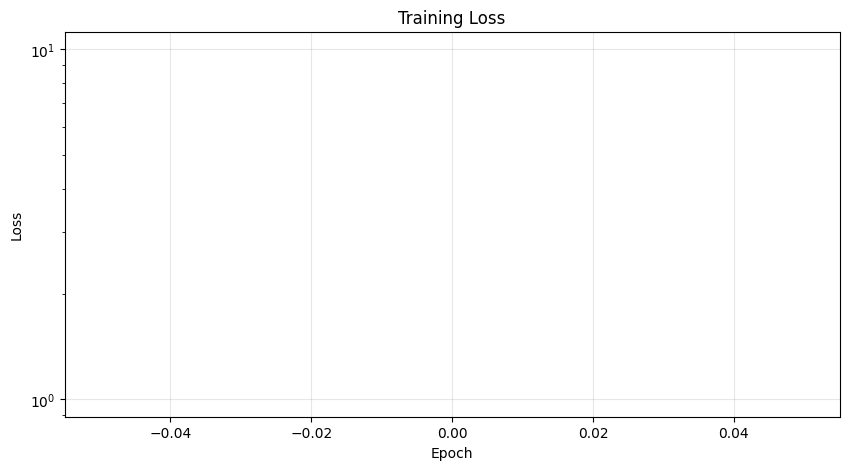

In [13]:
# Cell 1: Setup and training
data_path = "../Data/Kiwi Experiment/pickles/KiwiData.pkl"

# Load the data
data_dict = load_hyperspectral_data(data_path)

# Create dataset with handling of variable bands
dataset = HyperspectralDataset(
    data_dict,
    normalize=False,
    downscale_factor=2  # Adjust based on your memory constraints
)

# Get all processed data
all_data = dataset.get_all_data()
spatial_height, spatial_width = dataset.get_spatial_dimensions()

print(f"Prepared data dimensions: {spatial_height}x{spatial_width}")

# Create model
model = HyperspectralCAEVariable(
    excitations_data={ex: data.numpy() for ex, data in all_data.items()},
    k1=20,
    k3=20,
    filter_size=5,
    sparsity_target=0.75,
    sparsity_weight=1.0,
    dropout_rate=0.5,
    debug=False
)

print(f"Model created with {sum(p.numel() for p in model.parameters())} parameters")

# Train model (or load a previously trained model)
train_new_model = True  # Set to False to load a previously saved model

if train_new_model:
    model, losses = train_variable_cae(
        model,
        dataset,
        num_epochs=5,
        learning_rate=0.01,
        chunk_size=128,
        chunk_overlap=8
    )

    # Save the trained model
    torch.save(model.state_dict(), "hyperspectral_cae_model.pth")
    print("Model saved to hyperspectral_cae_model.pth")

    # Visualize training loss
    visualize_training_loss(losses)
else:
    # Load previously trained model
    model_path = "hyperspectral_cae_model.pth"
    model.load_state_dict(torch.load(model_path, map_location=device))
    print(f"Model loaded from {model_path}")

In [18]:
model.eval()
reconstructions = {}

for ex, data in all_data.items():
    # Add batch dimension
    data_batch = {ex: data.unsqueeze(0).to(device)}

    # Generate reconstruction
    with torch.no_grad():
        output = model(data_batch)

    # Store reconstruction
    if ex in output:
        reconstructions[ex] = output[ex][0].cpu()  # Remove batch dimension
        print(f"Generated reconstruction for excitation {ex}nm. "
              f"Shape: {reconstructions[ex].shape}, "
              f"Range: [{reconstructions[ex].min().item():.4f}, {reconstructions[ex].max().item():.4f}]")

Generated reconstruction for excitation 300.0nm. Shape: torch.Size([512, 696, 26]), Range: [0.9973, 1.0000]
Generated reconstruction for excitation 310.0nm. Shape: torch.Size([512, 696, 26]), Range: [0.9822, 1.0000]
Generated reconstruction for excitation 320.0nm. Shape: torch.Size([512, 696, 26]), Range: [0.9998, 1.0000]
Generated reconstruction for excitation 330.0nm. Shape: torch.Size([512, 696, 26]), Range: [0.9986, 1.0000]
Generated reconstruction for excitation 340.0nm. Shape: torch.Size([512, 696, 26]), Range: [0.9999, 1.0000]
Generated reconstruction for excitation 350.0nm. Shape: torch.Size([512, 696, 26]), Range: [0.9999, 1.0000]
Generated reconstruction for excitation 360.0nm. Shape: torch.Size([512, 696, 28]), Range: [0.9999, 1.0000]
Generated reconstruction for excitation 370.0nm. Shape: torch.Size([512, 696, 30]), Range: [0.9999, 1.0000]
Generated reconstruction for excitation 380.0nm. Shape: torch.Size([512, 696, 31]), Range: [0.9999, 1.0000]
Generated reconstruction for

Analyzing excitation wavelength: 500.0nm
Emission wavelength range: 520.0nm - 720.0nm


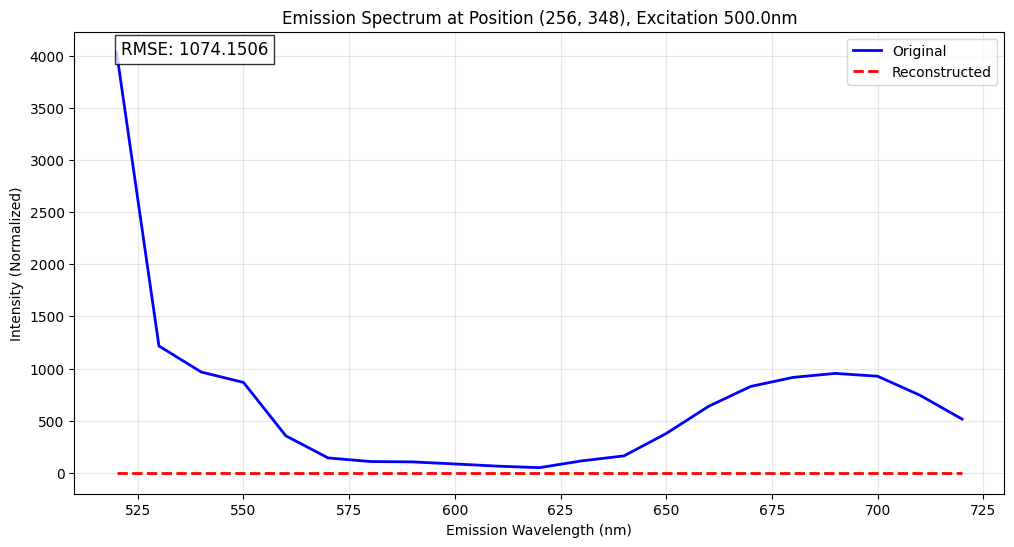

Center pixel RMSE: 1074.1506


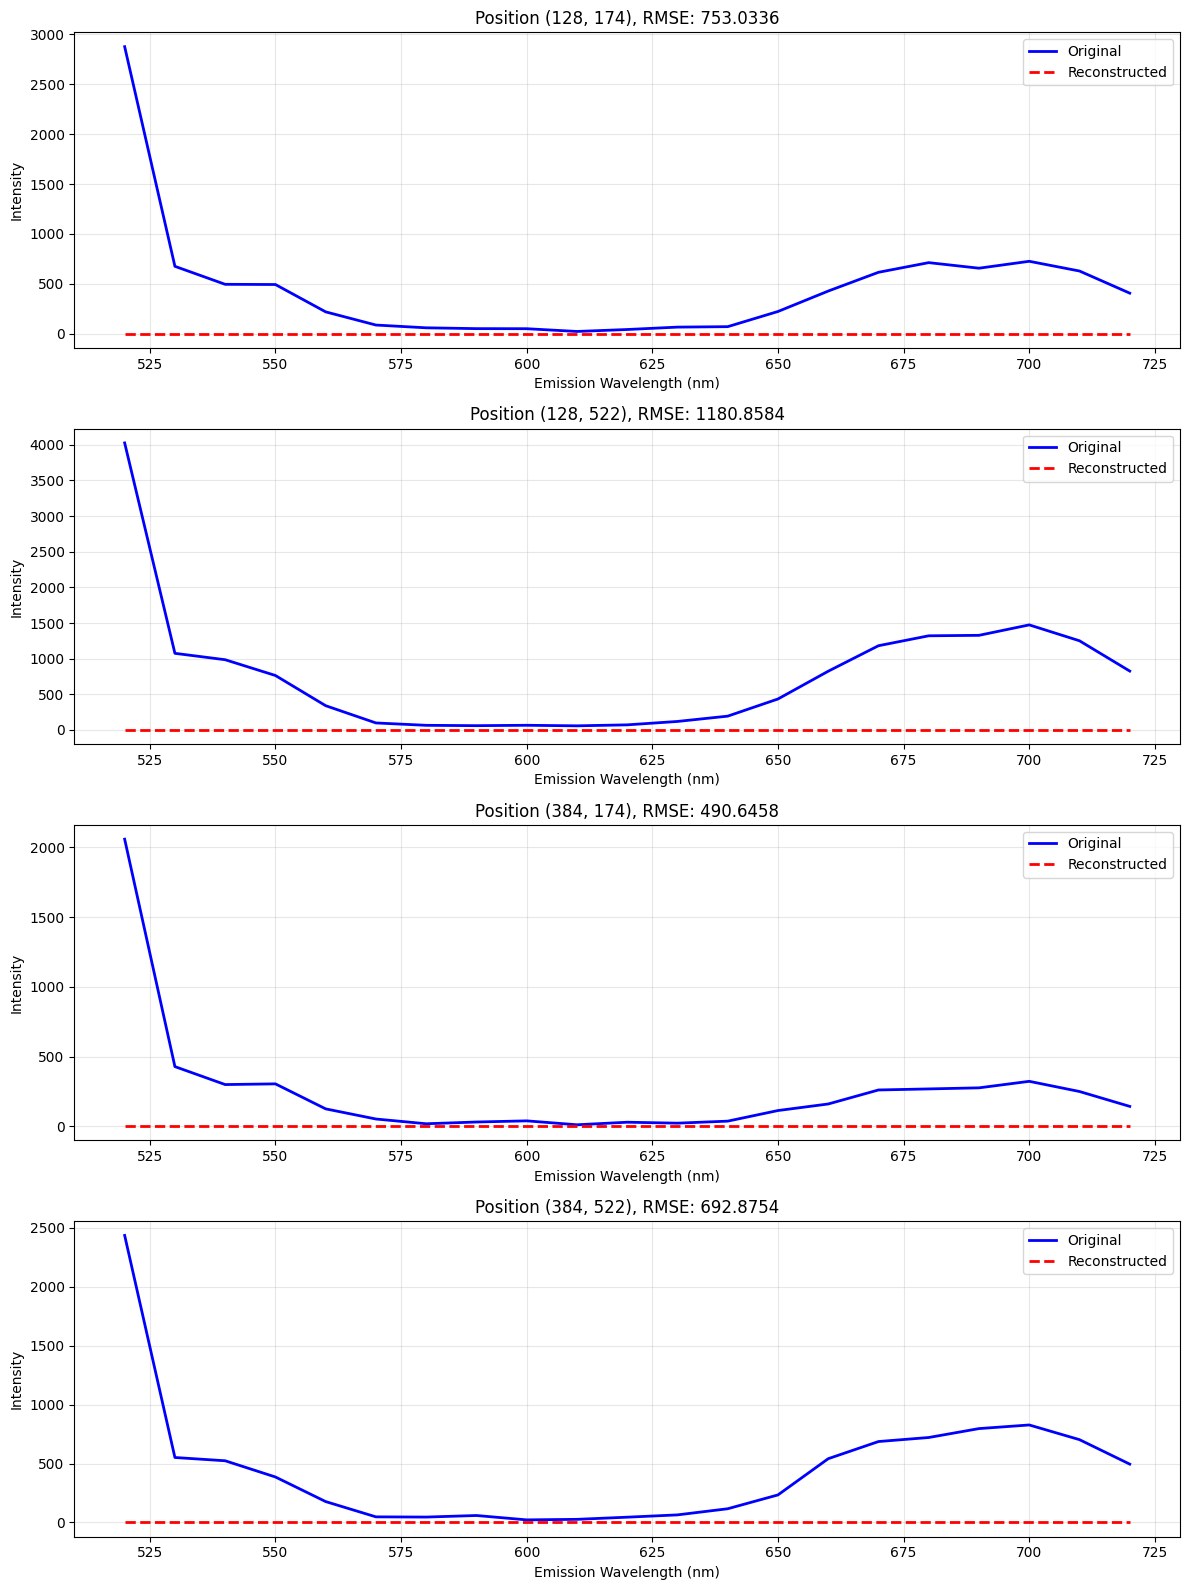

RMSE at different positions: ['753.0336', '1180.8584', '490.6458', '692.8754']


In [19]:
# Cell 3: Compare original and reconstructed spectra
# Select a specific excitation wavelength to analyze
excitation_to_analyze = list(all_data.keys())[len(all_data.keys()) - 1]  # First excitation
print(f"Analyzing excitation wavelength: {excitation_to_analyze}nm")

# Get original and reconstructed data
original_data = all_data[excitation_to_analyze]
reconstructed_data = reconstructions[excitation_to_analyze]

# Get emission wavelengths if available
emission_wavelengths = dataset.emission_wavelengths.get(excitation_to_analyze, None)
if emission_wavelengths:
    print(f"Emission wavelength range: {min(emission_wavelengths)}nm - {max(emission_wavelengths)}nm")

# Visualize spectrum at center pixel
center_y, center_x = spatial_height // 2, spatial_width // 2
rmse = visualize_emission_spectrum(
    original_data,
    reconstructed_data,
    excitation_to_analyze,
    y=center_y,
    x=center_x,
    wavelengths=emission_wavelengths
)
print(f"Center pixel RMSE: {rmse:.4f}")

# Visualize multiple spectra at different positions
h_quarter, w_quarter = spatial_height // 4, spatial_width // 4
positions = [
    (h_quarter, w_quarter),
    (h_quarter, spatial_width - w_quarter),
    (spatial_height - h_quarter, w_quarter),
    (spatial_height - h_quarter, spatial_width - w_quarter)
]

rmse_values = visualize_multiple_spectra(
    original_data,
    reconstructed_data,
    excitation_to_analyze,
    positions=positions,
    wavelengths=emission_wavelengths
)
print(f"RMSE at different positions: {[f'{rmse:.4f}' for rmse in rmse_values]}")

Using emission bands: R=650.0nm, G=550.0nm, B=470.0nm
Using emission bands: R=650.0nm, G=550.0nm, B=470.0nm


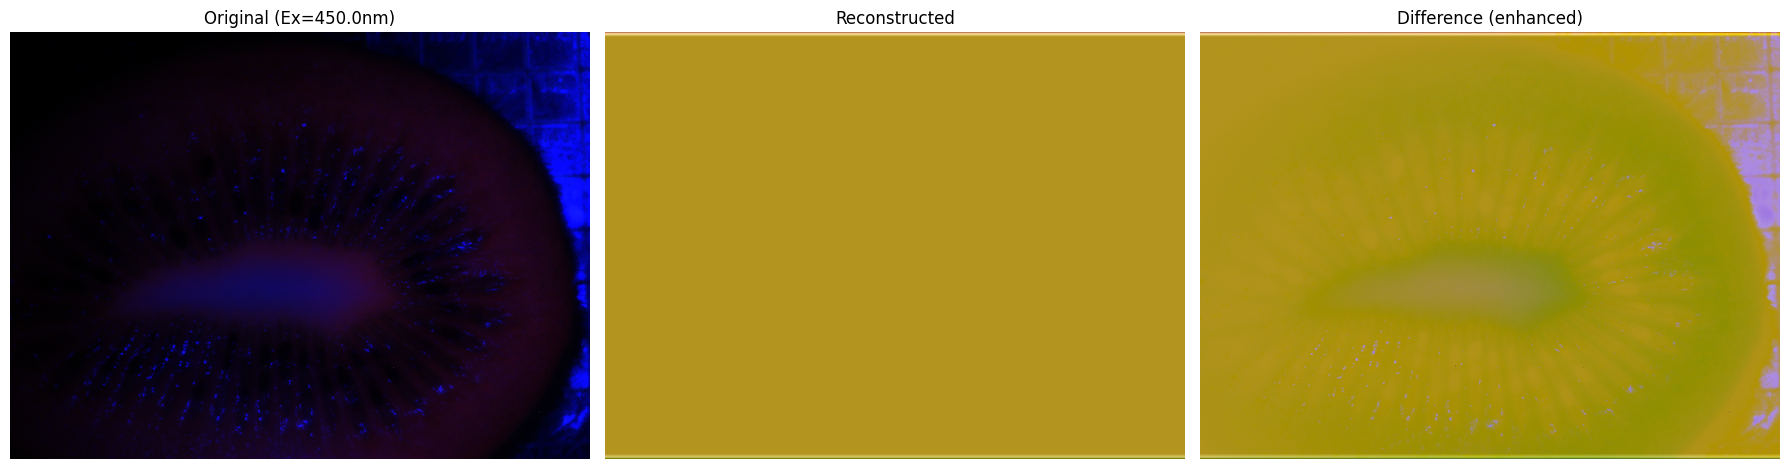

RMSE per channel: R=0.6520, G=0.5704, B=0.1626


(array([[[1.42786198e-03, 1.05537625e-03, 2.29699537e-03],
         [2.60740006e-03, 8.69133335e-04, 7.44971447e-04],
         [3.16612865e-03, 4.71815234e-03, 2.29699537e-03],
         ...,
         [1.90588534e-02, 2.99851000e-02, 5.81077754e-01],
         [1.02433572e-02, 3.32133099e-02, 4.97144282e-01],
         [1.89346913e-02, 3.36478762e-02, 3.85522723e-01]],
 
        [[5.83560951e-03, 1.36578095e-03, 2.23491434e-03],
         [2.23491434e-03, 0.00000000e+00, 7.26347137e-03],
         [2.97988579e-03, 2.17283331e-03, 5.27688116e-03],
         ...,
         [1.91830155e-02, 2.60119196e-02, 6.23727322e-01],
         [1.72585044e-02, 2.92401295e-02, 5.13595700e-01],
         [1.87484473e-02, 2.96126157e-02, 4.01539594e-01]],
 
        [[0.00000000e+00, 2.04867148e-03, 3.41445254e-03],
         [2.60740006e-03, 1.55202381e-03, 2.48323823e-03],
         [6.70474302e-03, 1.17953809e-03, 1.17953809e-03],
         ...,
         [1.50235910e-02, 2.92401295e-02, 7.10144043e-01],
        

In [16]:
def create_rgb_from_hyperspectral(data, emission_wavelengths, r_band=650, g_band=550, b_band=450):
    """
    Create an RGB visualization from hyperspectral data.

    Args:
        data: Hyperspectral data with shape [height, width, emission_bands]
        emission_wavelengths: List of emission wavelengths
        r_band, g_band, b_band: Target wavelengths for R, G, B channels (in nm)

    Returns:
        RGB image as numpy array
    """
    import numpy as np

    # Get closest wavelength indices for R, G, B
    r_idx = np.argmin(np.abs(np.array(emission_wavelengths) - r_band))
    g_idx = np.argmin(np.abs(np.array(emission_wavelengths) - g_band))
    b_idx = np.argmin(np.abs(np.array(emission_wavelengths) - b_band))

    # Create RGB image
    rgb = np.stack([
        data[:, :, r_idx],  # R channel
        data[:, :, g_idx],  # G channel
        data[:, :, b_idx]   # B channel
    ], axis=2)

    # Scale to [0, 1] for visualization
    rgb_min = np.min(rgb)
    rgb_max = np.max(rgb)
    rgb_normalized = (rgb - rgb_min) / (rgb_max - rgb_min + 1e-8)

    print(f"Using emission bands: R={emission_wavelengths[r_idx]}nm, "
          f"G={emission_wavelengths[g_idx]}nm, B={emission_wavelengths[b_idx]}nm")

    return rgb_normalized


def visualize_reconstruction_comparison(original_data, reconstructed_data,
                                       emission_wavelengths, excitation_wavelength,
                                       r_band=650, g_band=550, b_band=450):
    """
    Create a side-by-side comparison of original and reconstructed data.

    Args:
        original_data: Original hyperspectral data [height, width, emission_bands]
        reconstructed_data: Reconstructed hyperspectral data [height, width, emission_bands]
        emission_wavelengths: List of emission wavelengths
        excitation_wavelength: Excitation wavelength (for title)
        r_band, g_band, b_band: Target wavelengths for R, G, B channels
    """
    import numpy as np
    import matplotlib.pyplot as plt

    # Create RGB visualizations
    rgb_original = create_rgb_from_hyperspectral(
        original_data.numpy(), emission_wavelengths, r_band, g_band, b_band)

    rgb_reconstructed = create_rgb_from_hyperspectral(
        reconstructed_data.numpy(), emission_wavelengths, r_band, g_band, b_band)

    # Calculate difference
    diff = np.abs(rgb_original - rgb_reconstructed)
    # Enhance the difference for better visibility
    diff = diff / np.max(diff + 1e-8)

    # Create figure
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Plot original
    axes[0].imshow(rgb_original)
    axes[0].set_title(f'Original (Ex={excitation_wavelength}nm)')
    axes[0].axis('off')

    # Plot reconstruction
    axes[1].imshow(rgb_reconstructed)
    axes[1].set_title('Reconstructed')
    axes[1].axis('off')

    # Plot difference
    axes[2].imshow(diff)
    axes[2].set_title('Difference (enhanced)')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

    # Calculate RMSE per channel
    rmse_r = np.sqrt(np.mean((rgb_original[:,:,0] - rgb_reconstructed[:,:,0])**2))
    rmse_g = np.sqrt(np.mean((rgb_original[:,:,1] - rgb_reconstructed[:,:,1])**2))
    rmse_b = np.sqrt(np.mean((rgb_original[:,:,2] - rgb_reconstructed[:,:,2])**2))

    print(f"RMSE per channel: R={rmse_r:.4f}, G={rmse_g:.4f}, B={rmse_b:.4f}")

    return rgb_original, rgb_reconstructed


def visualize_multiple_excitations(model, all_data, emission_wavelengths,
                                  r_band=650, g_band=550, b_band=450,
                                  device='cuda' if torch.cuda.is_available() else 'cpu'):
    """
    Create RGB visualizations for multiple excitation wavelengths.

    Args:
        model: Trained HyperspectralCAEVariable model
        all_data: Dictionary mapping excitation wavelengths to data tensors
        emission_wavelengths: Dictionary mapping excitation wavelengths to emission wavelengths
        r_band, g_band, b_band: Target wavelengths for R, G, B channels
        device: Device to use for computation
    """
    import numpy as np
    import matplotlib.pyplot as plt
    import torch

    # Ensure model is in eval mode
    model.eval()

    # Generate reconstructions for all excitations
    reconstructions = {}
    for ex, data in all_data.items():
        # Add batch dimension
        data_batch = {ex: data.unsqueeze(0).to(device)}

        # Generate reconstruction
        with torch.no_grad():
            output = model(data_batch)

        # Store reconstruction
        reconstructions[ex] = output[ex][0].cpu()  # Remove batch dimension

    # Count excitations and determine grid layout
    num_excitations = len(all_data)
    num_to_show = min(9, num_excitations)  # Show maximum 9 excitations

    # Select excitations to visualize (choose evenly spaced ones)
    excitations_to_show = []
    if num_excitations <= num_to_show:
        excitations_to_show = sorted(all_data.keys())
    else:
        step = num_excitations // num_to_show
        indices = list(range(0, num_excitations, step))[:num_to_show]
        excitations_to_show = [sorted(all_data.keys())[i] for i in indices]

    # Determine grid layout
    grid_size = int(np.ceil(np.sqrt(num_to_show)))

    # Create a figure for RGB visualizations
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(grid_size*6, grid_size*4))
    if grid_size == 1:
        axes = np.array([[axes]])
    axes = axes.flatten()

    for i, ex in enumerate(excitations_to_show):
        if i >= len(axes):
            break

        # Get original and reconstructed data
        original = all_data[ex].numpy()
        reconstructed = reconstructions[ex].numpy()

        # Create RGB visualization
        rgb_original = create_rgb_from_hyperspectral(
            original, emission_wavelengths[ex], r_band, g_band, b_band)

        rgb_reconstructed = create_rgb_from_hyperspectral(
            reconstructed, emission_wavelengths[ex], r_band, g_band, b_band)

        # Create a side-by-side comparison
        comparison = np.hstack([rgb_original, rgb_reconstructed])

        # Plot
        axes[i].imshow(comparison)
        axes[i].set_title(f'Ex={ex}nm')
        axes[i].set_xlabel('Original | Reconstructed')
        axes[i].axis('off')

    # Hide any unused subplots
    for j in range(i+1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.suptitle('RGB Visualizations of Original vs Reconstructed Data', fontsize=16)
    plt.subplots_adjust(top=0.92)
    plt.show()


def create_spectral_signature_grid(model, all_data, emission_wavelengths,
                                  n_points=4, n_columns=4,
                                  device='cuda' if torch.cuda.is_available() else 'cpu'):
    """
    Create a grid of spectral signature plots for multiple locations.

    Args:
        model: Trained HyperspectralCAEVariable model
        all_data: Dictionary mapping excitation wavelengths to data tensors
        emission_wavelengths: Dictionary mapping excitation wavelengths to emission wavelengths
        n_points: Number of points to sample in each dimension
        n_columns: Number of excitations to show per row
        device: Device to use for computation
    """
    import numpy as np
    import matplotlib.pyplot as plt
    import torch

    # Ensure model is in eval mode
    model.eval()

    # Generate reconstructions for all excitations
    reconstructions = {}
    for ex, data in all_data.items():
        # Add batch dimension
        data_batch = {ex: data.unsqueeze(0).to(device)}

        # Generate reconstruction
        with torch.no_grad():
            output = model(data_batch)

        # Store reconstruction
        reconstructions[ex] = output[ex][0].cpu()  # Remove batch dimension

    # Get dimensions from first excitation
    first_ex = next(iter(all_data.keys()))
    height, width, _ = all_data[first_ex].shape

    # Sample points across the image
    y_points = np.linspace(height//8, height*7//8, n_points, dtype=int)
    x_points = np.linspace(width//8, width*7//8, n_points, dtype=int)

    # Select excitations to visualize (choose a subset if there are many)
    excitations_to_show = sorted(all_data.keys())[:n_columns]

    # Create grid of plots
    fig, axes = plt.subplots(n_points, n_points, figsize=(15, 15))

    # For each spatial location
    for i, y in enumerate(y_points):
        for j, x in enumerate(x_points):
            ax = axes[i, j]

            # Create a figure for this location
            for k, ex in enumerate(excitations_to_show):
                # Get original and reconstructed spectra
                orig_spectrum = all_data[ex][y, x].numpy()
                recon_spectrum = reconstructions[ex][y, x].numpy()

                # Get wavelengths
                wavelengths = emission_wavelengths[ex]

                # Plot with a slight offset between excitations for visibility
                offset = k * 0.02
                ax.plot(wavelengths, orig_spectrum + offset, 'b-', alpha=0.7, linewidth=1)
                ax.plot(wavelengths, recon_spectrum + offset, 'r--', alpha=0.7, linewidth=1)

            ax.set_title(f'Position ({y}, {x})')
            ax.set_xlabel('Emission Wavelength (nm)' if i == n_points-1 else '')
            ax.set_ylabel('Normalized Intensity' if j == 0 else '')
            ax.grid(True, alpha=0.3)

    # Add a legend to the first subplot
    blue_line = plt.Line2D([], [], color='blue', linestyle='-', label='Original')
    red_line = plt.Line2D([], [], color='red', linestyle='--', label='Reconstructed')
    axes[0, 0].legend(handles=[blue_line, red_line], loc='upper right')

    plt.tight_layout()
    plt.suptitle('Spectral Signatures at Different Locations', fontsize=16)
    plt.subplots_adjust(top=0.95)
    plt.show()



# For a single excitation wavelength:
excitation_to_analyze = 450.0  # Choose an excitation wavelength
original_data = all_data[excitation_to_analyze]
reconstructed_data = reconstructions[excitation_to_analyze]
emission_waves = dataset.emission_wavelengths[excitation_to_analyze]

visualize_reconstruction_comparison(
    original_data,
    reconstructed_data,
    emission_waves,
    excitation_to_analyze
)
#
# # For multiple excitation wavelengths:
# visualize_multiple_excitations(
#     model,
#     all_data,
#     dataset.emission_wavelengths
# )
#
# # For spectral signatures across the image:
# create_spectral_signature_grid(
#     model,
#     all_data,
#     dataset.emission_wavelengths
# )

Using separate normalization for original and reconstructed images
Using emission bands: R=650.0nm, G=550.0nm, B=520.0nm
Using emission bands: R=650.0nm, G=550.0nm, B=520.0nm


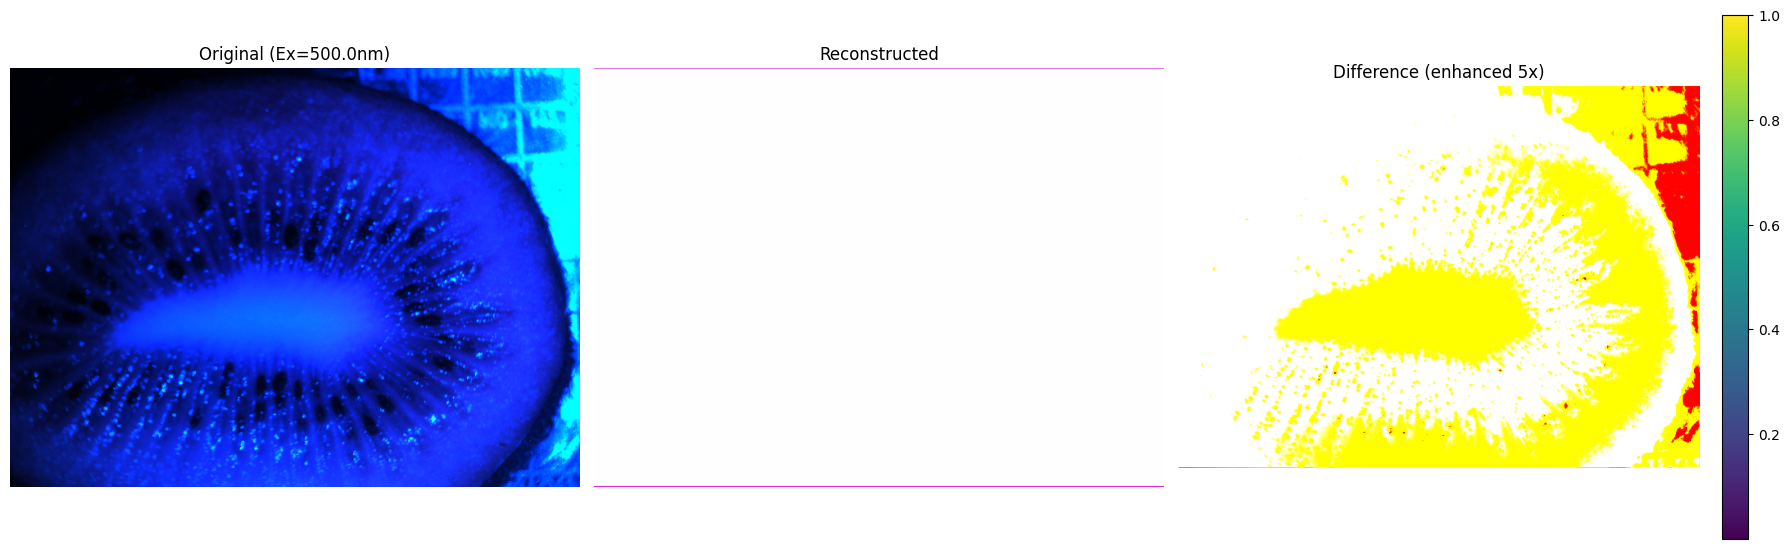

RMSE per channel: R=0.9547, G=0.8516, B=0.4768


(array([[[0.00254532, 0.00353861, 0.01030544],
         [0.        , 0.00316613, 0.01583064],
         [0.00415942, 0.00533896, 0.01868637],
         ...,
         [0.00893966, 1.        , 1.        ],
         [0.01378197, 0.993854  , 1.        ],
         [0.01378197, 0.97398806, 1.        ]],
 
        [[0.00415942, 0.00384902, 0.01868637],
         [0.0062081 , 0.00316613, 0.01999007],
         [0.00105538, 0.00682891, 0.01030544],
         ...,
         [0.01005711, 1.        , 1.        ],
         [0.01154706, 0.999255  , 1.        ],
         [0.01520983, 0.95356345, 1.        ]],
 
        [[0.00124162, 0.00235908, 0.01682394],
         [0.00124162, 0.00440775, 0.01645145],
         [0.00192451, 0.00204867, 0.01614105],
         ...,
         [0.01229203, 1.        , 1.        ],
         [0.00949839, 1.        , 1.        ],
         [0.00614601, 0.9870872 , 1.        ]],
 
        ...,
 
        [[0.00595977, 0.01371989, 0.04494661],
         [0.00713931, 0.01005711, 0.05283

In [17]:
def create_rgb_from_hyperspectral(data, emission_wavelengths, r_band=650, g_band=550, b_band=450,
                            normalization_range=None):
    """
    Create an RGB visualization from hyperspectral data.

    Args:
        data: Hyperspectral data with shape [height, width, emission_bands]
        emission_wavelengths: List of emission wavelengths
        r_band, g_band, b_band: Target wavelengths for R, G, B channels (in nm)
        normalization_range: Optional tuple (min, max) for consistent normalization

    Returns:
        RGB image as numpy array
    """
    import numpy as np

    # Get closest wavelength indices for R, G, B
    r_idx = np.argmin(np.abs(np.array(emission_wavelengths) - r_band))
    g_idx = np.argmin(np.abs(np.array(emission_wavelengths) - g_band))
    b_idx = np.argmin(np.abs(np.array(emission_wavelengths) - b_band))

    # Create RGB image
    rgb = np.stack([
        data[:, :, r_idx],  # R channel
        data[:, :, g_idx],  # G channel
        data[:, :, b_idx]   # B channel
    ], axis=2)

    # Scale to [0, 1] for visualization
    if normalization_range is None:
        # Normalize based on this data only
        rgb_min = np.min(rgb)
        rgb_max = np.max(rgb)
    else:
        # Use provided normalization range
        rgb_min, rgb_max = normalization_range

    rgb_normalized = (rgb - rgb_min) / (rgb_max - rgb_min + 1e-8)
    # Clip to ensure values are in [0, 1]
    rgb_normalized = np.clip(rgb_normalized, 0, 1)

    print(f"Using emission bands: R={emission_wavelengths[r_idx]}nm, "
          f"G={emission_wavelengths[g_idx]}nm, B={emission_wavelengths[b_idx]}nm")

    return rgb_normalized


def visualize_reconstruction_comparison(original_data, reconstructed_data,
                                       emission_wavelengths, excitation_wavelength,
                                       r_band=650, g_band=550, b_band=450,
                                       use_consistent_normalization=True):
    """
    Create a side-by-side comparison of original and reconstructed data.

    Args:
        original_data: Original hyperspectral data [height, width, emission_bands]
        reconstructed_data: Reconstructed hyperspectral data [height, width, emission_bands]
        emission_wavelengths: List of emission wavelengths
        excitation_wavelength: Excitation wavelength (for title)
        r_band, g_band, b_band: Target wavelengths for R, G, B channels
        use_consistent_normalization: Whether to use the same normalization for both images
    """
    import numpy as np
    import matplotlib.pyplot as plt

    # Convert to numpy if needed
    if hasattr(original_data, 'numpy'):
        original_data_np = original_data.numpy()
    else:
        original_data_np = original_data

    if hasattr(reconstructed_data, 'numpy'):
        reconstructed_data_np = reconstructed_data.numpy()
    else:
        reconstructed_data_np = reconstructed_data

    # Calculate normalization range if using consistent normalization
    if use_consistent_normalization:
        # Get R, G, B indices
        r_idx = np.argmin(np.abs(np.array(emission_wavelengths) - r_band))
        g_idx = np.argmin(np.abs(np.array(emission_wavelengths) - g_band))
        b_idx = np.argmin(np.abs(np.array(emission_wavelengths) - b_band))

        # Get min and max across both original and reconstructed for these bands
        combined_min = min(
            np.min(original_data_np[:, :, r_idx]),
            np.min(original_data_np[:, :, g_idx]),
            np.min(original_data_np[:, :, b_idx]),
            np.min(reconstructed_data_np[:, :, r_idx]),
            np.min(reconstructed_data_np[:, :, g_idx]),
            np.min(reconstructed_data_np[:, :, b_idx])
        )

        combined_max = max(
            np.max(original_data_np[:, :, r_idx]),
            np.max(original_data_np[:, :, g_idx]),
            np.max(original_data_np[:, :, b_idx]),
            np.max(reconstructed_data_np[:, :, r_idx]),
            np.max(reconstructed_data_np[:, :, g_idx]),
            np.max(reconstructed_data_np[:, :, b_idx])
        )

        normalization_range = (combined_min, combined_max)

        print(f"Using consistent normalization range: [{combined_min:.4f}, {combined_max:.4f}]")
    else:
        normalization_range = None
        print("Using separate normalization for original and reconstructed images")

    # Create RGB visualizations
    rgb_original = create_rgb_from_hyperspectral(
        original_data_np, emission_wavelengths, r_band, g_band, b_band, normalization_range)

    rgb_reconstructed = create_rgb_from_hyperspectral(
        reconstructed_data_np, emission_wavelengths, r_band, g_band, b_band, normalization_range)

    # Calculate difference
    diff = np.abs(rgb_original - rgb_reconstructed)
    # Enhance the difference for better visibility (optional)
    enhanced_diff = 5 * diff  # Multiply by 5 to make differences more visible
    enhanced_diff = np.clip(enhanced_diff, 0, 1)  # Clip to [0, 1]

    # Create figure
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Plot original
    axes[0].imshow(rgb_original)
    axes[0].set_title(f'Original (Ex={excitation_wavelength}nm)')
    axes[0].axis('off')

    # Plot reconstruction
    axes[1].imshow(rgb_reconstructed)
    axes[1].set_title('Reconstructed')
    axes[1].axis('off')

    # Plot difference
    im = axes[2].imshow(enhanced_diff)
    axes[2].set_title('Difference (enhanced 5x)')
    axes[2].axis('off')
    fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

    # Calculate RMSE per channel
    rmse_r = np.sqrt(np.mean((rgb_original[:,:,0] - rgb_reconstructed[:,:,0])**2))
    rmse_g = np.sqrt(np.mean((rgb_original[:,:,1] - rgb_reconstructed[:,:,1])**2))
    rmse_b = np.sqrt(np.mean((rgb_original[:,:,2] - rgb_reconstructed[:,:,2])**2))

    print(f"RMSE per channel: R={rmse_r:.4f}, G={rmse_g:.4f}, B={rmse_b:.4f}")

    return rgb_original, rgb_reconstructed


def visualize_multiple_excitations(model, all_data, emission_wavelengths,
                                  r_band=650, g_band=550, b_band=450,
                                  use_consistent_normalization=True,
                                  device='cuda' if torch.cuda.is_available() else 'cpu'):
    """
    Create RGB visualizations for multiple excitation wavelengths.

    Args:
        model: Trained HyperspectralCAEVariable model
        all_data: Dictionary mapping excitation wavelengths to data tensors
        emission_wavelengths: Dictionary mapping excitation wavelengths to emission wavelengths
        r_band, g_band, b_band: Target wavelengths for R, G, B channels
        use_consistent_normalization: Whether to use the same normalization for all images
        device: Device to use for computation
    """
    import numpy as np
    import matplotlib.pyplot as plt
    import torch

    # Ensure model is in eval mode
    model.eval()

    # Generate reconstructions for all excitations
    reconstructions = {}
    for ex, data in all_data.items():
        # Add batch dimension
        data_batch = {ex: data.unsqueeze(0).to(device)}

        # Generate reconstruction
        with torch.no_grad():
            output = model(data_batch)

        # Store reconstruction if available
        if ex in output:
            reconstructions[ex] = output[ex][0].cpu()  # Remove batch dimension

    # Count excitations and determine grid layout
    excitations_to_show = sorted([ex for ex in all_data.keys() if ex in reconstructions])
    num_to_show = min(9, len(excitations_to_show))  # Show maximum 9 excitations

    # Select excitations to visualize (choose evenly spaced ones)
    if len(excitations_to_show) <= num_to_show:
        selected_excitations = excitations_to_show
    else:
        step = len(excitations_to_show) // num_to_show
        indices = list(range(0, len(excitations_to_show), step))[:num_to_show]
        selected_excitations = [excitations_to_show[i] for i in indices]

    # Determine grid layout
    grid_size = int(np.ceil(np.sqrt(num_to_show)))

    # For consistent normalization across all excitations
    if use_consistent_normalization:
        # Find global min and max for RGB bands across all excitations
        global_min = float('inf')
        global_max = float('-inf')

        for ex in selected_excitations:
            # Get original and reconstructed data
            original_np = all_data[ex].numpy()
            reconstructed_np = reconstructions[ex].numpy()

            # Get R, G, B indices for this excitation
            r_idx = np.argmin(np.abs(np.array(emission_wavelengths[ex]) - r_band))
            g_idx = np.argmin(np.abs(np.array(emission_wavelengths[ex]) - g_band))
            b_idx = np.argmin(np.abs(np.array(emission_wavelengths[ex]) - b_band))

            # Update global min/max
            for idx in [r_idx, g_idx, b_idx]:
                global_min = min(global_min, np.min(original_np[:,:,idx]), np.min(reconstructed_np[:,:,idx]))
                global_max = max(global_max, np.max(original_np[:,:,idx]), np.max(reconstructed_np[:,:,idx]))

        print(f"Using global normalization range: [{global_min:.4f}, {global_max:.4f}]")

    # Create a figure for RGB visualizations
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(grid_size*6, grid_size*4))
    if grid_size == 1:
        axes = np.array([[axes]])
    axes = axes.flatten()

    for i, ex in enumerate(selected_excitations):
        if i >= len(axes):
            break

        # Get original and reconstructed data
        original = all_data[ex].numpy()
        reconstructed = reconstructions[ex].numpy()

        # Get normalization range for this excitation
        if use_consistent_normalization:
            normalization_range = (global_min, global_max)
        else:
            # Use separate normalization for each excitation
            r_idx = np.argmin(np.abs(np.array(emission_wavelengths[ex]) - r_band))
            g_idx = np.argmin(np.abs(np.array(emission_wavelengths[ex]) - g_band))
            b_idx = np.argmin(np.abs(np.array(emission_wavelengths[ex]) - b_band))

            min_val = min(
                np.min(original[:,:,r_idx]), np.min(original[:,:,g_idx]), np.min(original[:,:,b_idx]),
                np.min(reconstructed[:,:,r_idx]), np.min(reconstructed[:,:,g_idx]), np.min(reconstructed[:,:,b_idx])
            )
            max_val = max(
                np.max(original[:,:,r_idx]), np.max(original[:,:,g_idx]), np.max(original[:,:,b_idx]),
                np.max(reconstructed[:,:,r_idx]), np.max(reconstructed[:,:,g_idx]), np.max(reconstructed[:,:,b_idx])
            )
            normalization_range = (min_val, max_val)

        # Create RGB visualization
        rgb_original = create_rgb_from_hyperspectral(
            original, emission_wavelengths[ex], r_band, g_band, b_band, normalization_range)

        rgb_reconstructed = create_rgb_from_hyperspectral(
            reconstructed, emission_wavelengths[ex], r_band, g_band, b_band, normalization_range)

        # Create a side-by-side comparison
        comparison = np.hstack([rgb_original, rgb_reconstructed])

        # Plot
        axes[i].imshow(comparison)
        axes[i].set_title(f'Ex={ex}nm')
        axes[i].set_xlabel('Original | Reconstructed')
        axes[i].axis('off')

    # Hide any unused subplots
    for j in range(i+1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.suptitle('RGB Visualizations of Original vs Reconstructed Data', fontsize=16)
    plt.subplots_adjust(top=0.92)
    plt.show()


# For a single excitation wavelength with consistent normalization:
excitation_to_analyze = 500.0  # Choose an excitation wavelength
original_data = all_data[excitation_to_analyze]
reconstructed_data = reconstructions[excitation_to_analyze]
emission_waves = dataset.emission_wavelengths[excitation_to_analyze]

# Compare with consistent normalization (default)
# visualize_reconstruction_comparison(
#     original_data,
#     reconstructed_data,
#     emission_waves,
#     excitation_to_analyze
# )

# Compare with separate normalization
visualize_reconstruction_comparison(
    original_data,
    reconstructed_data,
    emission_waves,
    excitation_to_analyze,
    use_consistent_normalization=False
)

# For multiple excitation wavelengths:
# visualize_multiple_excitations(
#     model,
#     all_data,
#     dataset.emission_wavelengths,
#     use_consistent_normalization=True  # Set to False for separate normalization
# )
